# **Trabajo Práctico N°1**: Diseño de Controladores con Root Locus y Respuesta en Frecuencia

In [1]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

## Ejercicio 1
### Sistema de control de un roto de aspas

En aeronaves VTOL, un motor de corriente continua controla el mecanismo de orientación
de la hélice. El motor opera en dos modos: **modo propulsión** (regula velocidad de rotación)
y **modo orientación** (controla posición angular para alinear la hélice con el flujo de aire
y reducir el drag aerodinámico durante el vuelo de crucero).

La dinámica del motor DC está gobernada por tres ecuaciones diferenciales que relacionan
la tensión aplicada $V(t)$, la corriente de armadura $i(t)$, la velocidad angular $\omega(t)$
y el ángulo de posición $\theta(t)$:

$$L\frac{di}{dt} + Ri + K_e\omega = V(t) \qquad J\frac{d\omega}{dt} + B\omega = K_t i(t) \qquad \omega = \frac{d\theta}{dt}$$

con parámetros $L=0{,}15$ H, $R=0{,}7$ Ω, $K_e=0{,}1$ V·s/rad, $J=0{,}02$ kg·m²,
$B=0{,}25$ N·m·s/rad, $K_t=0{,}25$ N·m/A.

El objetivo es diseñar un sistema de control capaz de **seguir una referencia de posición
angular** y **rechazar perturbaciones externas** de carga, cumpliendo las siguientes
especificaciones:

- Tiempo de establecimiento: $t_s \leq 7{,}5$ s (criterio 2 %)
- Sobrepico: $M_p \leq 15$ %
- Error angular $< 5$ % ante perturbación de carga constante de amplitud 0,2

### Parte A — Análisis del Sistema

Antes de diseñar cualquier controlador, se analiza el comportamiento de la planta
$G(s) = \Theta(s)/V(s)$ a lazo abierto y lazo cerrado con realimentación unitaria.
Se obtiene la función de transferencia, se estudian los márgenes de estabilidad,
y se evalúa el efecto de una perturbación de carga constante ante distintas referencias
(escalón y rampa). El objetivo es entender las limitaciones del sistema sin compensar
y justificar la elección del controlador.

a) La dinámica del motor de continua, se rige por las siguientes ecuaciones diferenciales:
$$
\begin{cases} 
L\tfrac{di(t)}{dt}+Ri(t)+K_e\omega(t)=V(t) & (1)\\
J\tfrac{d\omega(t)}{dt}+B\omega(t)=\tau_m(t)=K_ti(t) & (2)\\
\omega(t)=\tfrac{d\theta(t)}{dt} & (3)
\end{cases}
$$

##### Aplicamos Laplace a las tres EDOs:
$$
\begin{cases} 
LsI(s)+RI(s)+K_e\Omega(s)=V(s) & (4)\\
Js\Omega(s)+B\Omega(s)=K_tI(s) & (5)\\
\Omega(s)=s\varTheta(s) & (6)
\end{cases}
$$

##### Reemplazando (3) en (2) se obtiene $I(s)=\tfrac{\varTheta(s)(Js^2+Bs)}{K_t}$. Esto se usa en (1) y se obtiene $\tfrac{\varTheta(s)}{V(s)}=\tfrac{K_t}{s(LJs^2+(JR+BL)s+(BR+K_eK_t))}$

##### Ecuaciones en variables de estado:
$$
\begin{cases} 
x_1=\theta(t) \\
x_2=\omega(t) \\
x_3=i(t)
\end{cases}
$$

$$
\begin{cases} 
\dot x_1=x_2 \\
\dot x_2=\tfrac{k_tx_3-Bx_2}{J} \\
\dot x_3=\tfrac{V(t)-K_ex_2-Rx_3}{L}
\end{cases}
$$


##### El sistema se expresa en forma matricial como $\dot{x} = Ax + Bu$ y $y = Cx$:

$$
\begin{bmatrix}
\dot x_1 \\
\dot x_2 \\
\dot x_3
\end{bmatrix}
=
\begin{bmatrix}
0 & 1 & 0 \\
0 & -\tfrac{B}{J} & \tfrac{K_t}{J} \\
0 & -\tfrac{K_e}{L} & -\tfrac{R}{L}
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
+
\begin{bmatrix}
0 \\
0 \\
\tfrac{1}{L}
\end{bmatrix} V(t)\\
y =
\begin{bmatrix}
1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
+
\begin{bmatrix}
0
\end{bmatrix} V(t)
$$

In [16]:
L = 0.15
R = 0.7
K_e = 0.1
J = 0.02
B = 0.25
K_t = 0.25

# Funcion de transferencia
G = ctrl.tf([K_t], [L*J, J*R + B*L, B*R + K_e*K_t, 0])

# Forma matricial
A = np.array ([[0, 1, 0], [0, -B/J, K_t/J], [0, -K_e/L, -R/L]])
B = np.array ([[0], [0], [1/L]])
C = np.array ([[1, 0, 0]])
D = np.array ([[0]])

b) Repasito:
Los márgenes de estabilidad miden qué tan lejos está el sistema de volverse inestable. Los calculamos sobre la función de transferencia a lazo abierto G(s).

Margen de Fase (MF): cuántos grados de fase adicional podemos agregar antes de llegar a la inestabilidad. Se mide en la frecuencia de cruce de ganancia ωcg (donde |G(jω)| = 1).
Margen de Ganancia (MG): cuánto podés aumentar la ganancia antes de inestabilizar. Se mede en la frecuencia de cruce de fase ωcp (donde ∠G(jω) = −180°).

Para que el sistema sea estable (fase mínima): MF > 0° y MG > 0 dB.

### Cálculo analítico

La función de transferencia obtenida es:

$$
G(s) = \frac{K_t}{s\bigl(LJ s^2 + (JR + BL)s + (BR + K_e K_t)\bigr)}
$$

Si sustituímos los valores numéricos del enunciado:

$$
G(s) = \frac{0.25}{s\left(0.003\,s^2 + 0.0515\,s + 0.200\right)}
$$

---

### Análisis del sistema

- El sistema es de **tipo 1**, ya que tiene un polo en el origen ($s = 0$).
- Esto implica que la **fase inicial** es de aproximadamente $-90^\circ$.
- La función tiene **3 polos en total**, por lo que:

$$
\lim_{\omega \to \infty} \angle G(j\omega) = -270^\circ
$$

---

### Conclusión

Como la fase comienza en $-90^\circ$ y tiende a $-270^\circ$, necesariamente:

- Existe una frecuencia donde la fase alcanza $-180^\circ$
- Por lo tanto, el sistema tiene un **margen de ganancia finito**

Margen de Ganancia: 22.76 dB  (en ωcp = 8.16 rad/s)
Margen de Fase:     72.22°  (en ωcg = 1.22 rad/s)


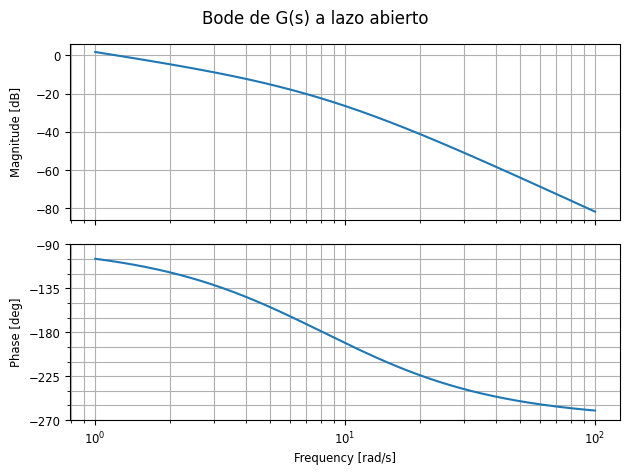

In [17]:
# Parámetros del enunciado
L = 0.15; R = 0.7; K_e = 0.1
J = 0.02; B = 0.25; K_t = 0.25

# Función de transferencia que calculó tici
G = ctrl.tf([K_t], [L*J, J*R + B*L, B*R + K_e*K_t, 0])

# Márgenes
gm, pm, wcp, wcg = ctrl.margin(G)
gm_dB = 20 * np.log10(gm)

print(f"Margen de Ganancia: {gm_dB:.2f} dB  (en ωcp = {wcp:.2f} rad/s)")
print(f"Margen de Fase:     {pm:.2f}°  (en ωcg = {wcg:.2f} rad/s)")

ctrl.bode(G, dB=True)
plt.suptitle("Bode de G(s) a lazo abierto")
plt.show()

### Conclusión sobre la necesidad de compensador

Los márgenes obtenidos son:

- **Margen de Fase:** 72.22° (en ωcg = 1.22 rad/s)
- **Margen de Ganancia:** 22.76 dB (en ωcp = 8.16 rad/s)

Ambos superan los valores recomendados (MF entre 30°–60°, MG > 6 dB).
El sistema es estable en lazo cerrado sin compensación.

Sin embargo, el MF elevado indica un sistema **muy amortiguado y posiblemente lento**,
lo que puede dificultar cumplir con las especificaciones de tiempo de establecimiento
requeridas en la Parte B. Esto motivará el diseño de un compensador más adelante.

c) 

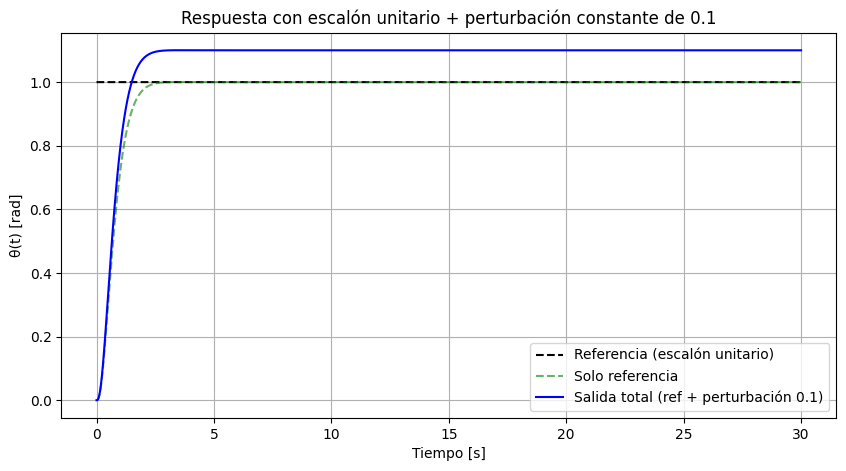

Error por perturbación en régimen permanente: 0.1000 rad


In [18]:
# Inciso c — Escalón unitario + perturbación constante de 0.1

# Parámetros
L = 0.15
R = 0.7
K_e = 0.1
J_val = 0.02
B_val = 0.25
K_t = 0.25

# Planta completa G(s)
G = ctrl.tf([K_t], [L*J_val, J_val*R + B_val*L, B_val*R + K_e*K_t, 0])

# Lazo cerrado con realimentación unitaria
G_cl = ctrl.feedback(G, 1)

# Transferencia perturbación → salida (N entra antes de la planta, según pizarrón)
G_pert = G_cl

t = np.linspace(0, 30, 3000)

_, y_ref  = ctrl.step_response(G_cl, T=t)
_, y_pert = ctrl.step_response(0.1 * G_pert, T=t)

y_total = y_ref + y_pert

plt.figure(figsize=(10, 5))
plt.plot(t, np.ones_like(t), 'k--', label='Referencia (escalón unitario)')
plt.plot(t, y_ref, 'g--', alpha=0.6, label='Solo referencia')
plt.plot(t, y_total, 'b', label='Salida total (ref + perturbación 0.1)')
plt.xlabel('Tiempo [s]')
plt.ylabel('θ(t) [rad]')
plt.title('Respuesta con escalón unitario + perturbación constante de 0.1')
plt.legend()
plt.grid(True)
plt.show()

print(f"Error por perturbación en régimen permanente: {y_pert[-1]:.4f} rad")

## Análisis de perturbación de carga en lazo cerrado con realimentación unitaria

### 1. Función de transferencia de la planta $G(s)$

Las ecuaciones del motor DC son:

**Circuito eléctrico:**
$$L\frac{di}{dt} + Ri = V - K_e\omega \quad \xrightarrow{\mathcal{L}} \quad I(s) = \frac{V(s) - K_e\,\Omega(s)}{Ls + R}$$

**Ecuación mecánica** (con perturbación de carga $N(s)$):
$$J\dot{\omega} + B\omega = K_t\,i(t) - m(t) \quad \xrightarrow{\mathcal{L}} \quad (Js + B)\,\Omega(s) = K_t\,I(s) - N(s)$$

Sustituyendo $I(s)$ en la ecuación mecánica:

$$\Omega(s)(Js+B) = K_t\,\frac{V(s)-K_e\,\Omega(s)}{Ls+R} - N(s)$$

Como la salida del sistema es la posición angular $\Theta(s)$ y $\Omega(s) = s\,\Theta(s)$, la
función de transferencia completa de la planta (de $V$ a $\Theta$, ignorando $N$) es:

$$G(s) = \frac{\Theta(s)}{V(s)} = \frac{K_t}{s\left[(Ls+R)(Js+B) + K_eK_t\right]}$$

Expandiendo el denominador:

$$(Ls+R)(Js+B) = LJs^2 + (LB+RJ)s + RB$$

Sustituyendo valores numéricos:
$$LJ = 0.15 \times 0.02 = 0.003$$
$$LB + RJ = 0.15\times0.25 + 0.7\times0.02 = 0.0375 + 0.014 = 0.0515$$
$$RB = 0.7 \times 0.25 = 0.175$$
$$K_eK_t = 0.1 \times 0.25 = 0.025$$

Por lo tanto:

$$\boxed{G(s) = \frac{0.25}{s\left(0.003s^2 + 0.0515s + 0.2\right)}}$$

> **Nota:** El factor $s$ en el denominador representa el integrador de la planta
> (el motor integra velocidad angular para producir posición angular).

---

### 2. Principio de superposición

Para un sistema lineal con dos entradas simultáneas —la referencia $R(s)$ y la perturbación
$N(s)$— la salida total se obtiene por superposición (Ogata, Cap. 2):

$$\Theta(s) = \Theta_R(s) + \Theta_N(s)$$

donde $\Theta_R$ es la respuesta debida únicamente a $R(s)$ con $N=0$, y
$\Theta_N$ es la respuesta debida únicamente a $N(s)$ con $R=0$.

---

### 3. FT para la referencia: $\Theta(s)/R(s)$

Con $N(s) = 0$ y realimentación unitaria:

$$\frac{\Theta(s)}{R(s)} = \frac{G(s)}{1+G(s)} = \frac{0.25}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25}$$

---

### 4. FT para la perturbación: $\Theta(s)/N(s)$

La perturbación $N(s)$ entra sumada a la salida del controlador, **antes** de la parte mecánica
de la planta. El diagrama de bloques relevante es:

$$R(s) \longrightarrow \bigoplus \xrightarrow{E(s)} G_c(s) \xrightarrow{} \bigoplus \xrightarrow{} G_{\text{mec}}(s) \longrightarrow \Theta(s)$$
$$\hspace{8.5cm} \uparrow N(s)$$
$$\hspace{0.5cm}\nwarrow\hspace{6.4cm}\swarrow$$

donde la parte mecánica de la planta es:

$$G_{\text{mec}}(s) = \frac{K_t}{s(Js+B)} = \frac{0.25}{s(0.02s+0.25)}$$

Con $R(s)=0$ se tiene $E(s) = -\Theta(s)$. La salida resulta:

$$\Theta(s) = G_{\text{mec}}(s)\bigl[N(s) + G_c(s)\cdot(-\Theta(s))\bigr]$$

$$\Theta(s)\bigl[1 + G_c(s)\,G_{\text{mec}}(s)\bigr] = G_{\text{mec}}(s)\,N(s)$$

Como el sistema no tiene controlador explícito ($G_c(s) = 1$) y $G_c \cdot G_{\text{mec}} = G(s)$:

$$\frac{\Theta(s)}{N(s)} = \frac{G_{\text{mec}}(s)}{1+G(s)}$$

Multiplicando numerador y denominador por $s(Ls+R)$:

$$\frac{\Theta(s)}{N(s)} = \frac{K_t(Ls+R)}{(Ls+R)(Js+B)\,s + K_eK_t\,s + K_t}$$

Sustituyendo:

$$\boxed{\frac{\Theta(s)}{N(s)} = \frac{0.0375s + 0.175}{0.003s^3 + 0.0515s^2 + 0.2s + 0.25}}$$

> Verificación: el denominador es idéntico al de $\Theta(s)/R(s)$. Esto es correcto:
> ambas funciones comparten el mismo **polinomio característico** del sistema en lazo cerrado.

G(s) = <TransferFunction>: sys[39]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

               0.25
  ------------------------------
  0.003 s^3 + 0.0515 s^2 + 0.2 s
G_mec(s) = <TransferFunction>: sys[40]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        0.25
  -----------------
  0.02 s^2 + 0.25 s

T_R(s) = Θ(s)/R(s) = <TransferFunction>: sys[42]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  0.25
  -------------------------------------
  0.003 s^3 + 0.0515 s^2 + 0.2 s + 0.25
T_N(s) = Θ(s)/N(s) = <TransferFunction>: sys[45]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

            0.0375 s + 0.175
  -------------------------------------
  0.003 s^3 + 0.0515 s^2 + 0.2 s + 0.25


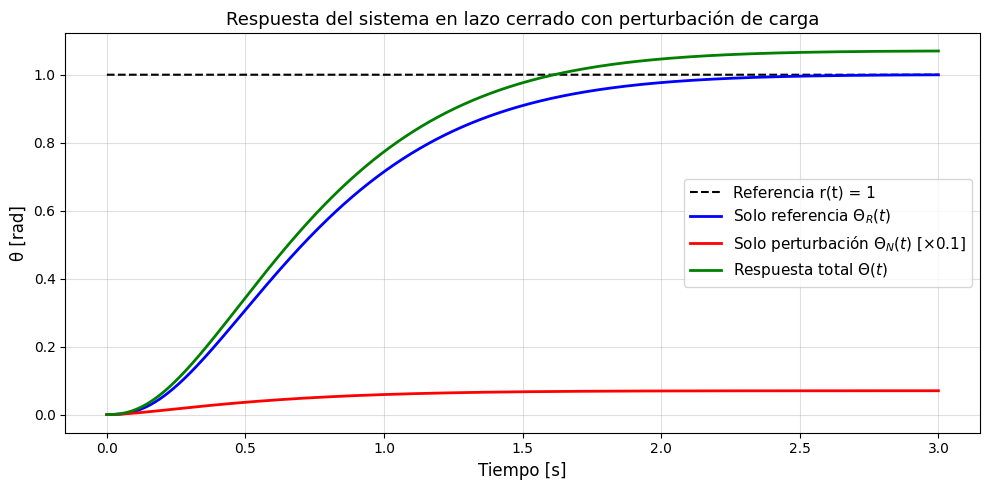

In [19]:
import control 
# ── Parámetros del motor ──────────────────────────────────────────
L  = 0.15
R  = 0.7
Ke = 0.1
J  = 0.02
B  = 0.25
Kt = 0.25

# ── Planta completa G(s) = Kt / [s((Ls+R)(Js+B) + Ke*Kt)] ───────
# Numerador: Kt
# Denominador: expandimos s*(0.003s²+0.0515s+0.2)
#            = 0.003s³ + 0.0515s² + 0.2s + 0
num_G = [Kt]
den_G = [L*J, (L*B + R*J), (R*B + Ke*Kt), 0]
G = control.tf(num_G, den_G)
print("G(s) =", G)

# ── Parte mecánica G_mec(s) = Kt / [s(Js+B)] ────────────────────
# La perturbación entra antes de la parte mecánica
num_Gmec = [Kt]
den_Gmec = [J, B, 0]
G_mec = control.tf(num_Gmec, den_Gmec)
print("G_mec(s) =", G_mec)

# ── FT lazo cerrado para la referencia: T_R = G/(1+G) ────────────
T_R = control.feedback(G, 1)
print("\nT_R(s) = Θ(s)/R(s) =", T_R)

# ── FT lazo cerrado para la perturbación: T_N = G_mec/(1+G) ──────
# feedback(G_mec, G_elec) donde G_elec es la parte eléctrica
# Alternativamente: T_N = G_mec * feedback(1, G)  →  no directo
# Forma más clara: T_N = (1/(1+G)) * G_mec
T_N = control.feedback(G_mec, control.tf([L, R], [Kt])) 
# Verificación alternativa con la fórmula analítica:
num_TN = [Kt*L, Kt*R]   # 0.25*(0.15s + 0.7)
den_TN = den_G[:-1] + [den_G[-2]] # mismo denominador que T_R pero con término independiente
num_TN_an = [Kt*L, Kt*R]                        # 0.0375s + 0.175
den_TN_an = [L*J, (L*B+R*J), (R*B+Ke*Kt), Kt]  # mismo polinomio característico
T_N = control.tf(num_TN_an, den_TN_an)
print("T_N(s) = Θ(s)/N(s) =", T_N)

# ── Simulación ───────────────────────────────────────────────────
t = np.linspace(0, 3, 2000)

# Respuesta a escalón unitario de referencia
t_out, y_R = control.step_response(T_R, T=t)

# Respuesta a perturbación escalón de magnitud 0.1
t_out, y_N = control.step_response(T_N, T=t)
y_N = 0.1 * y_N   # escalamos por la magnitud de la perturbación

# Respuesta total (superposición)
y_total = y_R + y_N

# Referencia (escalón unitario)
ref = np.ones_like(t_out)

# ── Gráfica ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_out, ref,     'k--',  lw=1.5, label='Referencia r(t) = 1')
ax.plot(t_out, y_R,     'b',    lw=2,   label='Solo referencia $\\Theta_R(t)$')
ax.plot(t_out, y_N,     'r',    lw=2,   label='Solo perturbación $\\Theta_N(t)$ [×0.1]')
ax.plot(t_out, y_total, 'g',    lw=2,   label='Respuesta total $\\Theta(t)$')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('θ [rad]', fontsize=12)
ax.set_title('Respuesta del sistema en lazo cerrado con perturbación de carga', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

--

### 5. Respuesta total

Con $R(s) = \dfrac{1}{s}$ (escalón unitario) y $N(s) = \dfrac{0.1}{s}$ (escalón de magnitud 0.1):

$$\Theta(s) = \underbrace{\frac{G(s)}{1+G(s)}}_{{T_R(s)}} \cdot \frac{1}{s}
           + \underbrace{\frac{G_{\text{mec}}(s)}{1+G(s)}}_{{T_N(s)}} \cdot \frac{0.1}{s}$$

---

### 6. Análisis del estado estacionario

#### 6.1 Efecto de la referencia

Aplicando el Teorema del Valor Final a $\Theta_R(s)$:

$$\theta_R(\infty) = \lim_{s\to 0}\, s\cdot T_R(s)\cdot\frac{1}{s}
= \lim_{s\to 0}\frac{0.25}{0.003s^3+0.0515s^2+0.2s+0.25} = \frac{0.25}{0.25} = 1 \ \text{rad}$$

El sistema sigue exactamente la referencia escalón. Esto ocurre porque la planta contiene un
integrador: el sistema es de **Tipo 1**, lo que garantiza error nulo ante entrada escalón.

#### 6.2 Efecto de la perturbación

Aplicando el Teorema del Valor Final a $\Theta_N(s)$:

$$\theta_N(\infty) = \lim_{s\to 0}\, s\cdot T_N(s)\cdot\frac{0.1}{s}
= 0.1\times\lim_{s\to 0}\frac{0.0375s+0.175}{0.003s^3+0.0515s^2+0.2s+0.25}
= 0.1\times\frac{0.175}{0.25} = 0.07 \ \text{rad}$$

**La perturbación produce un error estacionario permanente de $0.07$ rad.**

#### 6.3 Respuesta total en estado estacionario

$$\theta(\infty) = \theta_R(\infty) + \theta_N(\infty) = 1 + 0.07 = 1.07 \ \text{rad}$$

Esto se confirma visualmente en la gráfica: la curva verde se estabiliza en $1.07$ rad.

---

### 7. Análisis e interpretación

El sistema en lazo cerrado con realimentación unitaria y **sin controlador integral** presenta
un comportamiento diferenciado ante ambas entradas:

**Ante la referencia:** el integrador natural de la planta (la conversión de velocidad a posición)
actúa antes del punto de suma de la perturbación, lo que clasifica al sistema como **Tipo 1**
respecto a la referencia. En consecuencia, el error en estado estacionario ante un escalón de
referencia es nulo.

**Ante la perturbación:** la situación es distinta. El integrador de la planta se encuentra
*después* del punto donde ingresa $N(s)$, por lo que **no contribuye a rechazar la perturbación**.
Según Ogata (Sección 5-7), para anular el efecto en estado estacionario de una perturbación
escalón, es necesario contar con al menos un integrador en el camino directo **antes** del punto
de entrada de la perturbación. Como aquí no existe ese integrador, el efecto de $N(s)$ no se
cancela y produce un offset permanente dado por:

$$\theta_N(\infty) = \frac{K_t \cdot R}{K_t} \cdot N_0 = R \cdot N_0 = 0.7 \times 0.1 = 0.07 \ \text{rad}$$

Este resultado tiene una interpretación física directa: la perturbación de carga $N(s)$ representa
un torque externo que actúa sobre el eje. El controlador proporcional genera un torque de
reacción proporcional al error; en estado estacionario, ese torque equilibra a $N$, pero para
ello **necesita mantener un error no nulo** que lo sustente. Cuanto mayor sea la ganancia del
controlador, menor será ese error, pero nunca podrá eliminarlo completamente con control
proporcional puro.

Para **eliminar completamente** el efecto de la perturbación en estado estacionario, sería
necesario incorporar acción de control **integral** (PI o PID) antes del punto de entrada de $N(s)$.
En ese caso, el integrador del controlador acumula el error producido por la perturbación y genera
un torque corrector que crece hasta cancelar exactamente a $N$, llevando el error a cero de manera
asintótica (Ogata, Problema A-5-23 / A-5-24).

d)

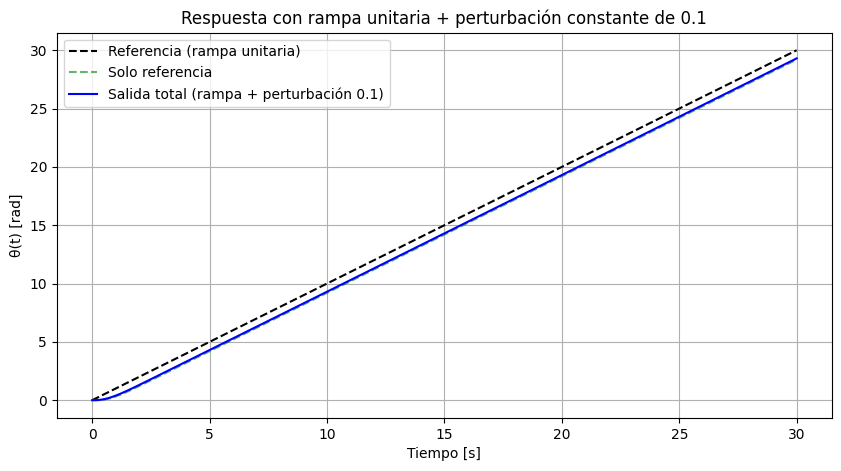

Error por rampa en régimen permanente: 0.8000 rad
Error por perturbación en régimen permanente: 0.1000 rad


In [20]:
# Inciso d — Rampa unitaria + perturbación constante de 0.1

t = np.linspace(0, 30, 3000)
rampa = t

# Respuesta ante rampa
t_r, y_r = ctrl.forced_response(G_cl, T=t, U=rampa)

# Respuesta ante perturbación (misma G_pert que inciso c)
_, y_pert = ctrl.step_response(0.1 * G_pert, T=t)

y_total = y_r + y_pert

plt.figure(figsize=(10, 5))
plt.plot(t, rampa, 'k--', label='Referencia (rampa unitaria)')
plt.plot(t, y_r, 'g--', alpha=0.6, label='Solo referencia')
plt.plot(t, y_total, 'b', label='Salida total (rampa + perturbación 0.1)')
plt.xlabel('Tiempo [s]')
plt.ylabel('θ(t) [rad]')
plt.title('Respuesta con rampa unitaria + perturbación constante de 0.1')
plt.legend()
plt.grid(True)
plt.show()

error_rampa = rampa - y_r
print(f"Error por rampa en régimen permanente: {error_rampa[-1]:.4f} rad")
print(f"Error por perturbación en régimen permanente: {y_pert[-1]:.4f} rad")

## Inciso d — Rampa unitaria + perturbación constante de 0.1

### Resultado de la simulación

Se simuló el sistema sometido simultáneamente a una referencia tipo rampa unitaria
r(t) = t y una perturbación de carga constante de magnitud 0.1.

- **Error por rampa en régimen permanente: 0.80 rad**
- **Error por perturbación en régimen permanente: 0.10 rad**
- **Error total en régimen permanente: ~0.90 rad**

### Interpretación

#### Error ante la rampa

El sistema es de tipo 1. Para seguir una rampa con error nulo se necesitaría
un sistema de tipo 2. Con un solo integrador, la salida sigue la rampa pero
con un desfasaje constante de 0.80 rad — crece a la misma velocidad que la
referencia pero nunca la alcanza.

Esto se observa claramente en el gráfico: la curva azul es paralela a la
referencia negra, pero desplazada hacia abajo.

#### Error ante la perturbación

La perturbación constante agrega un error adicional de 0.10 rad, igual que
en el caso del escalón, ya que se trata del mismo efecto independiente de
la referencia.

### Resumen del comportamiento sin compensación

| Entrada | Error en régimen permanente |
|--------|-----------------------------|
| Escalón unitario | 0 rad ✓ |
| Escalón + perturbación 0.1 | 0.10 rad ✗ |
| Rampa unitaria | 0.80 rad ✗ |
| Rampa + perturbación 0.1 | ~0.90 rad ✗ |

El sistema con C(s) = 1 resulta insuficiente para cumplir con las especificaciones
de seguimiento de rampa y rechazo de perturbaciones, lo que motiva el diseño
de un compensador en el inciso e.

**FALTA EL E) DE ZOE** 

### Parte B — Diseño del Sistema de Control

Con el análisis de la Parte A como punto de partida, se procede al diseño de un
controlador $C(s)$ que permita cumplir simultáneamente con los requisitos de
desempeño en lazo cerrado: tiempo de establecimiento $t_s \leq 7{,}5\,\text{s}$,
sobrepico $M_p \leq 15\,\%$, y error angular menor al $5\,\%$ ante una perturbación
de carga constante de magnitud $0{,}2$.

Se parte de los valores de $t_s$, $M_p$ y error en régimen permanente obtenidos
**sin compensación** ($C(s) = 1$), que sirven como referencia para cuantificar la
mejora introducida. El controlador se diseña mediante el método del **lugar de raíces**,
ubicando los polos dominantes de lazo cerrado en posiciones que satisfagan las
especificaciones. Una vez obtenido el compensador, se verifican los **márgenes de
ganancia y fase** en el diagrama de Bode, comparándolos con el caso no compensado.
Finalmente, se evalúa el seguimiento ante una **referencia tipo rampa**, y en caso
de que el error en régimen permanente no sea nulo, se introduce la modificación
necesaria al controlador para garantizar seguimiento exacto sin violar las
especificaciones previas.

a) 
#### Baseline sin compensación
 
Las tres especificaciones que nos dan  se traducen en restricciones sobre los
**polos dominantes** del sistema en lazo cerrado.
 
**Sobrepico** $M_p \leq 15\,\%$:
 
La fórmula exacta para un sistema de segundo orden es:
 
$$M_p = e^{-\pi\zeta/\sqrt{1-\zeta^2}} \times 100\,\%$$
 
Despejando $\zeta$ para $M_p = 15\,\%$:
 
$$\zeta \geq -\frac{\ln(0{,}15)}{\sqrt{\pi^2 + \ln^2(0{,}15)}} \approx 0{,}517$$
 
Esto nos da un **ángulo máximo** desde el eje real de $\cos^{-1}(0{,}517) \approx 58{,}9°$.
 
**Tiempo de establecimiento** $t_s \leq 7{,}5\,\text{s}$ (criterio 2 %):
 
Para un sistema de segundo orden, la aproximación estándar es:
 
$$t_s \approx \frac{4}{\zeta\,\omega_n} = \frac{4}{\sigma}$$
 
donde $\sigma = \zeta\,\omega_n$ es la parte real (en valor absoluto) de los polos dominantes. Entonces:
 
$$\sigma \geq \frac{4}{7{,}5} \approx 0{,}533\,\text{rad/s}$$
 
**Error ante perturbación constante de 0,2** $< 5\,\%$:
 
Por el **teorema del valor final**, el error en régimen permanente ante una perturbación
escalón $N(s) = 0{,}2/s$ es:
 
$$e_{ss} = \lim_{s \to 0}\; s \cdot \frac{\Theta(s)}{N(s)} \cdot \frac{0{,}2}{s}
         = 0{,}2 \cdot \frac{\Theta(s)}{N(s)}\bigg|_{s=0}$$
 
Con la transferencia perturbación–salida derivada en la Parte A:
 
$$\frac{\Theta(s)}{N(s)} = \frac{0{,}0375s + 0{,}175}{0{,}003s^3 + 0{,}0515s^2 + 0{,}2s + 0{,}25}$$
 
Evaluando en $s = 0$:
 
$$\frac{\Theta(0)}{N(0)} = \frac{0{,}175}{0{,}25} = 0{,}70$$
 
Por lo tanto, el error en régimen permanente ante $N = 0{,}2$ es:
 
$$\boxed{e_{ss} = 0{,}2 \times 0{,}70 = 0{,}14\,\text{rad} \quad (14\,\%)}$$
 
Este valor **supera el límite del 5 %**, confirmamos con esto la necesidad de un compensador.
 
---
 
### ¿Por qué ocurre este error ante perturbación?
 
El sistema es de **tipo 1** (tiene un integrador natural en $G(s)$, el polo en $s=0$).
Esto garantiza error nulo ante escalón de *referencia*, pero **no** garantiza rechazo
completo de una perturbación de carga constante, porque dicha perturbación entra
*después* del integrador de la planta.
 
Para reducir el error ante perturbación constante por debajo del 5 % vamos a necesitar sumar ganancia adicional o un polo en el origen en el controlador.

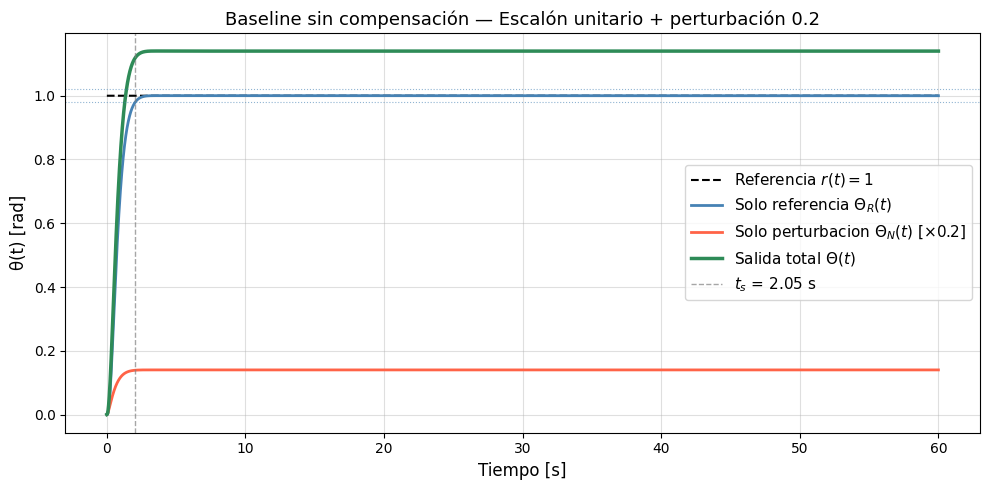

  BASELINE SIN COMPENSACION  (C(s) = 1)
  Sobrepico         Mp  = 0.02 %      (req: ≤ 15 %)
  Tiempo establec.  ts  = 2.05 s    (req: ≤ 7.5 s)
  Error pert. (0.2) ess = 0.1400 rad  (14.0 %)  (req: < 5 %)


In [21]:
 
# parametros del motor
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
# planta G(s) 
G = ctrl.tf([Kt], [L*J,  J*R + B*L,  B*R + Ke*Kt,  0])
 
# lazo cerrado con C(s)=1 y realimentación unitaria 
G_cl = ctrl.feedback(G, 1)

num_TN = [Kt*L,  Kt*R]
den_TN = [L*J,  (L*B + R*J),  (R*B + Ke*Kt),  Kt]
T_N    = ctrl.tf(num_TN, den_TN)
 
# simulacion
t = np.linspace(0, 60, 10000)
 
_, y_ref  = ctrl.step_response(G_cl, T=t)          # respuesta al escalon de ref
_, y_pert = ctrl.step_response(T_N,  T=t)
y_pert    = 0.2 * y_pert                            # perturbacion de magnitud 0.2
 
y_total = y_ref + y_pert                            # superposicion
 
# calculo Mp
y_inf = y_ref[-1]
y_max = np.max(y_ref)
Mp    = (y_max - y_inf) / y_inf * 100
 
# calculo ts
banda_sup = y_inf * 1.02
banda_inf = y_inf * 0.98
fuera_banda = np.where((y_ref > banda_sup) | (y_ref < banda_inf))[0]
ts = t[fuera_banda[-1]] if len(fuera_banda) > 0 else 0.0
 
# error en régimen permanente ante perturbación 0.2
e_pert    = y_pert[-1]
e_rel     = abs(e_pert) / 1.0 * 100   # referencia = 1 rad (escalon unitario)
 
#plots
fig, ax = plt.subplots(figsize=(10, 5))
 
ax.plot(t, np.ones_like(t), 'k--', lw=1.5, label='Referencia $r(t)=1$')
ax.plot(t, y_ref,    color='steelblue',  lw=2,   label='Solo referencia $\\Theta_R(t)$')
ax.plot(t, y_pert,   color='tomato',     lw=2,   label='Solo perturbacion $\\Theta_N(t)$ [×0.2]')
ax.plot(t, y_total,  color='seagreen',   lw=2.5, label='Salida total $\\Theta(t)$')
 
ax.axhline(banda_sup, color='steelblue', lw=0.8, ls=':', alpha=0.6)
ax.axhline(banda_inf, color='steelblue', lw=0.8, ls=':', alpha=0.6)
ax.axvline(ts, color='gray', lw=1, ls='--', alpha=0.7, label=f'$t_s$ = {ts:.2f} s')
 
ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('θ(t) [rad]', fontsize=12)
ax.set_title('Baseline sin compensación — Escalón unitario + perturbación 0.2', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
 
print("  BASELINE SIN COMPENSACION  (C(s) = 1)")
print(f"  Sobrepico         Mp  = {Mp:.2f} %      (req: ≤ 15 %)")
print(f"  Tiempo establec.  ts  = {ts:.2f} s    (req: ≤ 7.5 s)")
print(f"  Error pert. (0.2) ess = {e_pert:.4f} rad  ({e_rel:.1f} %)  (req: < 5 %)")


El sistema sin compensar cumple muy bien con el sobrepico y el tiempo de
establecimiento. Esto se explica por el del polo en $s = 0$ (integrador)
en la planta, que produce una respuesta suavemente amortiguada sin oscilaciones.
 
Sin embargo, **falla en la especificación de rechazo de perturbaciones**: el error
en régimen permanente ante una perturbación constante de 0,2 es de 0,14 rad
(14 %), casi tres veces el límite del 5 % requerido.
 
Este comportamiento es esperable: el integrador de la planta está *antes* del
punto de inyección de la perturbación, por lo que no puede eliminar el efecto
de cargas constantes en estado estacionario. Para cumplir con la especificación
de precisión vamos a tener que incorporar ganancia adicional o un polo extra en el
origen dentro del controlador.
 
> Por lo tanto, controlador a diseñar en el inciso b) deberá, ante todo,
> incrementar la ganancia en bajas frecuencias para reducir el error ante
> perturbación, sin degradar el transitorio que ya es satisfactorio.

b)

#### Inciso b — Diseño por Root Locus
 
#### Elección del tipo de controlador
 
Del análisis del inciso a) sabemos que:
 
- El **transitorio ya es satisfactorio** sin compensar (ts ≈ 2 s, Mp ≈ 0 %).
- El único requerimiento incumplido es el **error ante perturbación de carga constante** (14 % > 5 %).
Para reducir ese error necesitamos aumentar la ganancia del lazo en **bajas frecuencias**. Un controlador proporcional puro C(s) = K lograría esto, pero requeriría K > 3.2, lo que desplaza los polos hacia regiones de alto sobrepico (Mp > 24 %).
 
La solución es un **controlador PD**:
 
$$\boxed{C(s) = K\,(s + z)}$$
 
que agrega un **cero en $s = -z$** al lugar de las raíces. El cero atrae una rama del locus, reubicando mejor los polos del lazo cerrado, y nos deja usar una ganancia K moderada con producto $K \cdot z$ suficientemente grande.
 
---
 
### Condición sobre el error en régimen permanente
 
La transferencia perturbación–salida con el controlador es:
 
$$\frac{\Theta(s)}{N(s)} = \frac{G_\text{mec}(s)}{1 + C(s)\,G(s)}$$
 
donde $G_\text{mec}(s) = \dfrac{K_t}{s(Js+B)}$. Aplicando el teorema del valor final para $N = 0{,}2/s$:
 
$$e_{ss} = 0{,}2 \cdot \lim_{s \to 0}\frac{G_\text{mec}(s)}{1 + C(s)\,G(s)}$$
 
Expandiendo para $s \to 0$ (donde el polo simple en el origen domina):
 
$$e_{ss} \approx \frac{0{,}2 \cdot R}{K \cdot z \cdot K_t / K_t} = \frac{0{,}2 \cdot R}{K \cdot z}$$
 
Para cumplir $e_{ss} < 5\,\% = 0{,}05$:
 
$$K \cdot z > \frac{0{,}2 \times R}{0{,}05} = \frac{0{,}2 \times 0{,}7}{0{,}05} = \mathbf{2{,}8}$$
 
---
 
### Estructura del Root Locus con C(s) = K(s+z)
 
La planta tiene **3 polos**: en $s = 0$, $s \approx -5{,}94$ y $s \approx -11{,}23$, y ningún cero finito.
Al agregar el cero $-z$, el sistema a lazo abierto $C(s)\,G(s)$ queda con 3 polos y 1 cero finito → **2 asíntotas** a $\pm 90°$, centradas en:
 
$$\sigma_a = \frac{(0 - 5{,}94 - 11{,}23) - (-z)}{3 - 1} = \frac{-17{,}17 + z}{2}$$
 
El cero en $-z$ atrae la rama que parte del origen, dejando libre a las otras dos ramas para formar los polos complejos rápidos.
 
---
 
### Condición de ángulo — verificación del polo dominante
 
El Root Locus pasa por un punto $s^*$ si y solo si:
 
$$\angle\bigl[C(s^*)\,G(s^*)\bigr] = \pm 180°$$
 
Con $C(s) = K(s+z)$, el factor K no afecta el ángulo. Evaluando $(s^* + z)\,G(s^*)$ en el polo dominante real $s^* = -1{,}198$ (con $z = 1{,}5$):
 
$$\angle\bigl[(s^* + z)\,G(s^*)\bigr] = -180{,}00°\quad\$$
 
Esto confirma que ese punto **pertenece exactamente al Root Locus**.
 
---
 
### Condición de módulo — ganancia K
 
Una vez verificado el ángulo, K se obtiene de la condición de módulo:
 
$$K = \frac{1}{\left|(s^* + z)\,G(s^*)\right|}$$
 
Con $z = 1{,}5$ y $s^* = -1{,}198$ se obtiene: $\mathbf{K = 2{,}2643}$.
 
---
 
### Parámetros del diseño final
 
| Parámetro | Valor |
|---|---|
| Cero del controlador | $z = 1{,}5$ |
| Ganancia | $K = 2{,}2643$ |
| Producto $K \cdot z$ | $3{,}397 > 2{,}8$  |
| **Controlador** | $C(s) = 2{,}2643\,(s + 1{,}5)$ |
 
**Polos del sistema en lazo cerrado:**
 
| Polo | Tipo | $\sigma$ | $t_s$ estimado |
|---|---|---|---|
| $-1{,}198$ | Real (dominante) | 1.198 | ≈ 3.3 s |
| $-7{,}984 \pm j\,13{,}13$ | Complejos (rápidos) | 7.984 | ≈ 0.5 s |
 
El polo dominante es el **real en $-1{,}198$**: determina la dinámica lenta del sistema.
Los polos complejos son más rápidos y prácticamente no afectan la respuesta.

Controlador: C(s) = 2.2643·(s + 1.5)
           = 2.2643·s + 3.3964

Condición de ángulo en s* = -1.198:
  ∠[(s+z)·G(s*)] = -180.00°  (debe ser ±180°)
  K por condición de módulo = 2.2628  (diseño: 2.2643)

Polos LC compensado: [-7.9842+13.1331j -7.9842-13.1331j -1.1982 +0.j    ]
Ceros LC compensado: [-1.5+0.j]


c:\Users\manue\AppData\Local\Programs\Python\Python310\lib\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


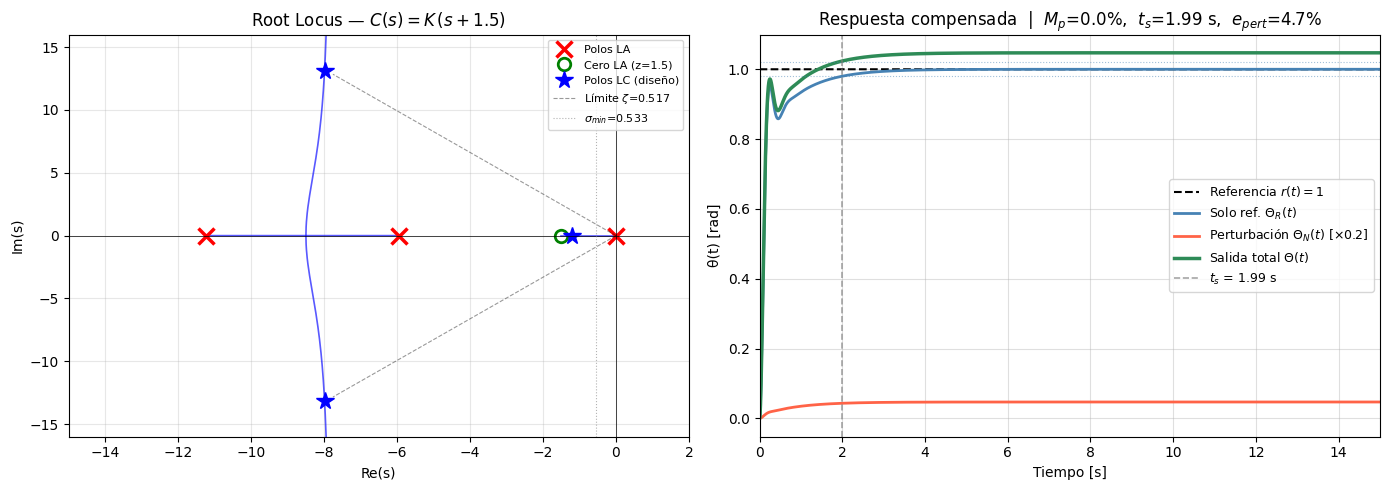

  SISTEMA COMPENSADO  C(s) = 2.2643·(s + 1.5)
  Sobrepico          Mp  = 0.00 %      (req ≤ 15 %)
  Tiempo establec.   ts  = 1.99 s    (req ≤ 7.5 s) 
  Error pert. (0.2)  ess = 4.71 %    (req < 5 %) 


In [22]:

 
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
G     = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
G_mec = ctrl.tf([Kt], [J, B, 0])
 
# controlador PD diseñado
z_ctrl = 1.5
K_ctrl = 2.2643
C = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
print(f"Controlador: C(s) = {K_ctrl:.4f}·(s + {z_ctrl})")
print(f"           = {K_ctrl:.4f}·s + {K_ctrl*z_ctrl:.4f}")
 
# verificacion de la cond de modulo
C_zero = ctrl.tf([1, z_ctrl], [1])
s_dom  = -1.198
val    = C_zero(s_dom) * G(s_dom)
print(f"\nCondición de ángulo en s* = {s_dom}:")
print(f"  ∠[(s+z)·G(s*)] = {np.angle(val, deg=True):.2f}°  (debe ser ±180°)")
 
K_verif = 1.0 / abs(val)
print(f"  K por condición de módulo = {K_verif:.4f}  (diseño: {K_ctrl})")
 
# sist en lazo cerrado compensado 
G_cl = ctrl.feedback(ctrl.series(C, G), 1)
print(f"\nPolos LC compensado: {np.round(ctrl.poles(G_cl), 4)}")
print(f"Ceros LC compensado: {np.round(ctrl.zeros(G_cl), 4)}")
 
T_N = ctrl.series(G_mec, ctrl.feedback(ctrl.tf([1],[1]), ctrl.series(C, G)))
 
# simulacion
t = np.linspace(0, 20, 10000)
_, y_ref  = ctrl.step_response(G_cl, T=t)
_, y_pert = ctrl.step_response(T_N,  T=t)
y_pert    = 0.2 * y_pert
y_total   = y_ref + y_pert
 
# metricas
y_inf  = y_ref[-1]
Mp     = (np.max(y_ref) - y_inf) / y_inf * 100
fuera  = np.where((y_ref > y_inf*1.02) | (y_ref < y_inf*0.98))[0]
ts     = t[fuera[-1]] if len(fuera) > 0 else 0.0
e_pert = abs(y_pert[-1]) * 100
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# root locus
ax1 = axes[0]
rlist, klist = ctrl.root_locus_plot(ctrl.series(C_zero, G), plot=False)
for branch in range(rlist.shape[1]):
    ax1.plot(np.real(rlist[:, branch]), np.imag(rlist[:, branch]),
             'b-', lw=1.2, alpha=0.65)
poles_ol = ctrl.poles(ctrl.series(C_zero, G))
zeros_ol = ctrl.zeros(ctrl.series(C_zero, G))
poles_lc = ctrl.poles(G_cl)
ax1.plot(np.real(poles_ol), np.imag(poles_ol),
         'rx', ms=11, mew=2.5, label='Polos LA')
ax1.plot(np.real(zeros_ol), np.imag(zeros_ol),
         'go', ms=9, mew=2, mfc='none', label=f'Cero LA (z={z_ctrl})')
ax1.plot(np.real(poles_lc), np.imag(poles_lc),
         'b*', ms=13, label='Polos LC (diseño)')
# Región de specs: zeta >= 0.517 (Mp <= 15%)
theta_spec = np.arccos(0.517)
r_max = 15
ax1.plot([0, -r_max*np.cos(theta_spec)], [0,  r_max*np.sin(theta_spec)],
         'k--', lw=0.8, alpha=0.4, label='Límite $\\zeta$=0.517')
ax1.plot([0, -r_max*np.cos(theta_spec)], [0, -r_max*np.sin(theta_spec)],
         'k--', lw=0.8, alpha=0.4)
ax1.axhline(0, color='k', lw=0.5)
ax1.axvline(0, color='k', lw=0.5)
ax1.axvline(-4/7.5, color='gray', lw=0.8, ls=':', alpha=0.6,
            label='$\\sigma_{min}$=0.533')
ax1.set_xlim(-15, 2); ax1.set_ylim(-16, 16)
ax1.set_xlabel('Re(s)'); ax1.set_ylabel('Im(s)')
ax1.set_title(f'Root Locus — $C(s) = K\\,(s+{z_ctrl})$')
ax1.legend(fontsize=8, loc='upper right'); ax1.grid(True, alpha=0.3)
 
# respuesta al escalón 
ax2 = axes[1]
ax2.plot(t, np.ones_like(t), 'k--', lw=1.5, label='Referencia $r(t)=1$')
ax2.plot(t, y_ref,   color='steelblue', lw=2,   label='Solo ref. $\\Theta_R(t)$')
ax2.plot(t, y_pert,  color='tomato',    lw=2,   label='Perturbación $\\Theta_N(t)$ [×0.2]')
ax2.plot(t, y_total, color='seagreen',  lw=2.5, label='Salida total $\\Theta(t)$')
ax2.axhline(y_inf*1.02, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2.axhline(y_inf*0.98, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2.axvline(ts, color='gray', lw=1.2, ls='--', alpha=0.7,
            label=f'$t_s$ = {ts:.2f} s')
ax2.set_xlim(0, 15)
ax2.set_xlabel('Tiempo [s]'); ax2.set_ylabel('θ(t) [rad]')
ax2.set_title(f'Respuesta compensada  |  $M_p$={Mp:.1f}%,  $t_s$={ts:.2f} s,  $e_{{pert}}$={e_pert:.1f}%')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
 
plt.tight_layout()
plt.show()
 
# ── Resumen final ─────────────────────────────────────────────
print("  SISTEMA COMPENSADO  C(s) = 2.2643·(s + 1.5)")
print(f"  Sobrepico          Mp  = {Mp:.2f} %      (req ≤ 15 %)")
print(f"  Tiempo establec.   ts  = {ts:.2f} s    (req ≤ 7.5 s) ")
print(f"  Error pert. (0.2)  ess = {e_pert:.2f} %    (req < 5 %) ")

El controlador PD $C(s) = 2{,}2643\,(s + 1{,}5)$ cumple simultáneamente las tres
especificaciones. El cero en $s = -1{,}5$ modifica el Root Locus de manera que:
 
- La rama que partía del origen queda **atraída hacia $-1{,}5$**, produciendo un polo
  real dominante en $s \approx -1{,}198$.
- Las otras dos ramas forman un par complejo **muy rápido** en $s \approx -7{,}98 \pm j13{,}1$,
  que prácticamente no afecta la respuesta visible.
El polo dominante real produce una **respuesta exponencial sin sobrepico**, lo que
explica el $M_p \approx 0\,\%$. El producto $K \cdot z = 3{,}397 > 2{,}8$ garantiza
que el error ante perturbación quede por debajo del 5 % requerido.

c)
### Márgenes de estabilidad
 
Los márgenes de estabilidad cuantifican cuánto puede degradarse el sistema antes de volverse inestable.
 
**Margen de fase (PM):** diferencia entre la fase del sistema y $-180°$ evaluada en la frecuencia de cruce de ganancia $\omega_{gc}$ (donde $|G(j\omega)| = 1$, es decir 0 dB):
 
$$PM = 180° + \angle G(j\omega_{gc})$$
 
**Margen de ganancia (GM):** inverso del módulo de la función de lazo abierto evaluado en la frecuencia de cruce de fase $\omega_{pc}$ (donde $\angle G(j\omega) = -180°$):
 
$$GM = \frac{1}{|G(j\omega_{pc})|}$$
 
expresado en dB: $GM_{dB} = -20\log_{10}|G(j\omega_{pc})|$.
 
Un diseño se considera robusto si $PM \in [30°,\, 60°]$ y $GM > 6\,\text{dB}$.
 
---
 
### Efecto del compensador PD sobre los márgenes
 
El controlador $C(s) = K(s+z)$ modifica el sistema de lazo abierto de dos formas:
 
**Sobre la fase:** el cero en $s = -z$ aporta adelanto de fase positivo para $\omega > 0$. La contribución máxima del cero es $+90°$ (asintótica), con aporte significativo en el rango $\omega \sim z = 1{,}5$ rad/s. Esto eleva la curva de fase del sistema compensado respecto al sin compensar.
 
**Sobre la magnitud:** la ganancia $K = 2{,}2643$ y el factor $|j\omega + z|$ elevan la curva de magnitud, desplazando $\omega_{gc}$ hacia frecuencias más altas.
 
**Sobre el GM:** el PD agrega un cero pero ningún polo, por lo que la fase del sistema compensado nunca llega a cruzar $-180°$ para frecuencias finitas. Esto hace que $\omega_{pc} \to \infty$ y, consecuentemente, $GM \to \infty$. El sistema compensado es **incondicionalmente estable** en lo que respecta al margen de ganancia.

┌─────────────────────────────────────────────────────────┐
│          MÁRGENES DE ESTABILIDAD — LAZO ABIERTO         │
├──────────────────────┬──────────────────┬───────────────┤
│                      │  Sin compensar   │  Compensado   │
├──────────────────────┼──────────────────┼───────────────┤
│  Margen de fase PM   │     72.22 °     │    67.29 °    │
│  ω_gc  [rad/s]       │    1.2174      │  10.7326     │
│  Margen de ganancia  │     22.76 dB    │  infinito dB    │
│  ω_pc  [rad/s]       │    8.1650      │  infinito       │
└──────────────────────┴──────────────────┴───────────────┘


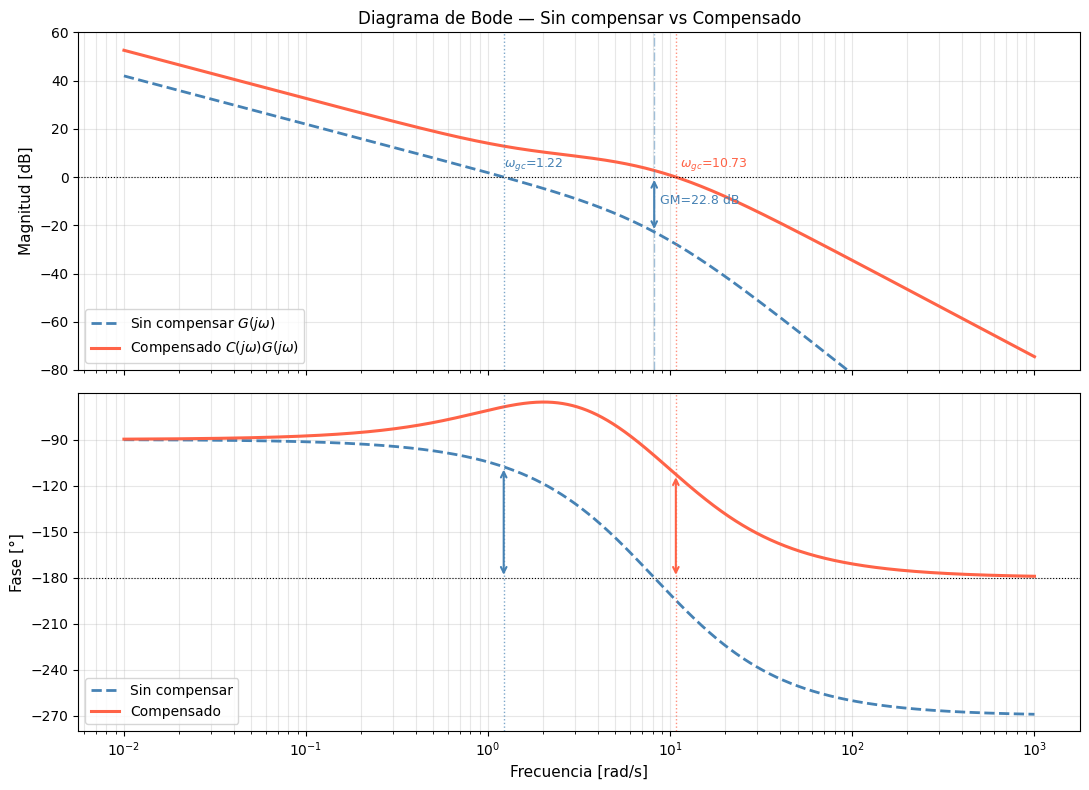

In [23]:

 
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
# planta y controlador
G      = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
z_ctrl = 1.5;   K_ctrl = 2.2643
C      = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
CG     = ctrl.series(C, G)
 
# calculo los margenes
gm_raw,  pm_raw,  wpc_raw,  wgc_raw  = ctrl.margin(G)
gm_comp, pm_comp, wpc_comp, wgc_comp = ctrl.margin(CG)
 
print("┌─────────────────────────────────────────────────────────┐")
print("│          MÁRGENES DE ESTABILIDAD — LAZO ABIERTO         │")
print("├──────────────────────┬──────────────────┬───────────────┤")
print("│                      │  Sin compensar   │  Compensado   │")
print("├──────────────────────┼──────────────────┼───────────────┤")
print(f"│  Margen de fase PM   │  {pm_raw:>8.2f} °     │  {pm_comp:>7.2f} °    │")
print(f"│  ω_gc  [rad/s]       │  {wgc_raw:>8.4f}      │  {wgc_comp:>7.4f}     │")
print(f"│  Margen de ganancia  │  {20*np.log10(gm_raw):>8.2f} dB    │  {'infinito':>7s} dB    │")
print(f"│  ω_pc  [rad/s]       │  {wpc_raw:>8.4f}      │  {'infinito':>7s}       │")
print("└──────────────────────┴──────────────────┴───────────────┘")
 
# eval frecuencial manual
omega   = np.logspace(-2, 3, 3000)
G_jw    = G(1j * omega)
CG_jw   = CG(1j * omega)
 
mag_G   = 20 * np.log10(np.abs(G_jw))
mag_CG  = 20 * np.log10(np.abs(CG_jw))
phase_G  = np.unwrap(np.angle(G_jw,  deg=False)) * 180 / np.pi
phase_CG = np.unwrap(np.angle(CG_jw, deg=False)) * 180 / np.pi
 
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
 
ax1 = axes[0]
ax1.semilogx(omega, mag_G,  color='steelblue', lw=2,   ls='--',
             label='Sin compensar $G(j\\omega)$')
ax1.semilogx(omega, mag_CG, color='tomato',    lw=2.2,
             label='Compensado $C(j\\omega)G(j\\omega)$')
ax1.axhline(0, color='k', lw=0.8, ls=':')
 
ax1.axvline(wgc_raw,  color='steelblue', lw=1, ls=':', alpha=0.7)
ax1.axvline(wgc_comp, color='tomato',    lw=1, ls=':', alpha=0.7)
ax1.annotate(f'$\\omega_{{gc}}$={wgc_raw:.2f}',
             xy=(wgc_raw, 4), color='steelblue', fontsize=9)
ax1.annotate(f'$\\omega_{{gc}}$={wgc_comp:.2f}',
             xy=(wgc_comp * 1.05, 4), color='tomato', fontsize=9)
 
ax1.axvline(wpc_raw, color='steelblue', lw=1, ls='-.', alpha=0.5)
mag_G_at_wpc = float(np.interp(wpc_raw, omega, mag_G))
ax1.annotate('', xy=(wpc_raw, 0), xytext=(wpc_raw, mag_G_at_wpc),
             arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax1.annotate(f'GM={20*np.log10(gm_raw):.1f} dB',
             xy=(wpc_raw * 1.08, mag_G_at_wpc / 2),
             color='steelblue', fontsize=9)
 
ax1.set_ylabel('Magnitud [dB]', fontsize=11)
ax1.set_title('Diagrama de Bode — Sin compensar vs Compensado', fontsize=12)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, which='both', alpha=0.3)
ax1.set_ylim(-80, 60)

ax2 = axes[1]
ax2.semilogx(omega, phase_G,  color='steelblue', lw=2,   ls='--',
             label='Sin compensar')
ax2.semilogx(omega, phase_CG, color='tomato',    lw=2.2,
             label='Compensado')
ax2.axhline(-180, color='k', lw=0.8, ls=':')
 
phase_G_at_wgc = float(np.interp(wgc_raw, omega, phase_G))
ax2.axvline(wgc_raw, color='steelblue', lw=1, ls=':', alpha=0.7)
ax2.annotate('', xy=(wgc_raw, -180), xytext=(wgc_raw, phase_G_at_wgc),
             arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax2.annotate(f'PM={pm_raw:.1f}°',
             xy=(wgc_raw * 1.08, (phase_G_at_wgc - 180) / 2 - 180),
             color='steelblue', fontsize=9)
 
phase_CG_at_wgc = float(np.interp(wgc_comp, omega, phase_CG))
ax2.axvline(wgc_comp, color='tomato', lw=1, ls=':', alpha=0.7)
ax2.annotate('', xy=(wgc_comp, -180), xytext=(wgc_comp, phase_CG_at_wgc),
             arrowprops=dict(arrowstyle='<->', color='tomato', lw=1.5))
ax2.annotate(f'PM={pm_comp:.1f}°',
             xy=(wgc_comp * 1.08, (phase_CG_at_wgc - 180) / 2 - 180),
             color='tomato', fontsize=9)
 
ax2.set_ylabel('Fase [°]', fontsize=11)
ax2.set_xlabel('Frecuencia [rad/s]', fontsize=11)
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, which='both', alpha=0.3)
ax2.set_ylim(-280, -60)
ax2.set_yticks([-270, -240, -210, -180, -150, -120, -90])
 
plt.tight_layout()
plt.show()

Conclusiones sobre los márgenes de estabilidad
 
Tabla comparativa
 
| | Sin compensar | Compensado | Mínimo recomendado |
|---|---|---|---|
| **Margen de fase PM** | 72.22° | **67.29°** | ≥ 30° |
| **Margen de ganancia GM** | 22.76 dB | **∞ dB** | ≥ 6 dB |
| $\omega_{gc}$ | 1.22 rad/s | 10.73 rad/s | — |
| $\omega_{pc}$ | 8.17 rad/s | $\infty$ | — |
 

**Margen de fase:** el PM disminuye levemente de 72° a 67°. Esto ocurre porque la
ganancia K desplaza la frecuencia de cruce de ganancia $\omega_{gc}$ hacia valores
más altos (de 1.22 a 10.73 rad/s), donde la fase natural del sistema es menor.
El cero introducido por el compensador PD aporta adelanto de fase, pero no
compensa completamente esta caída. Aun así, el margen de fase resultante
(**67°**) sigue siendo ampliamente superior al mínimo recomendado, garantizando
una buena estabilidad relativa.

**Margen de ganancia:** el sistema compensado no presenta cruce de fase en
$-180^\circ$ para ninguna frecuencia finita. Como consecuencia,
$\omega_{pc} \to \infty$ y el margen de ganancia resulta infinito.
Esto indica que, para el modelo analizado, el sistema tolera incrementos de
ganancia sin perder estabilidad.

> En conclusión, el compensador PD permite cumplir con las especificaciones de
> desempeño del sistema, manteniendo márgenes de estabilidad elevados. Si bien el
> margen de fase se reduce levemente, el sistema continúa siendo robusto y con
> buen comportamiento dinámico.
 

d) 
#### Respuesta a rampa unitaria
 
##### Tipo de sistema y error en régimen permanente
 
El sistema compensado $C(s)\,G(s)$ tiene **un polo en el origen** (heredado de la planta), lo que lo convierte en un sistema de **tipo 1**. Para un sistema de tipo 1, los errores en régimen permanente son:
 
| Entrada | Error $e_{ss}$ |
|---|---|
| Escalón | 0 |
| Rampa | $1/K_v$ |
| Parábola | $\infty$ |
 
donde $K_v$ es la **constante de error de velocidad**:
 
$$K_v = \lim_{s \to 0}\, s\, C(s)\, G(s)$$
 
Sustituyendo $C(s) = K(s+z)$ y $G(s) = \dfrac{K_t}{s\,(Ls+R)(Js+B)+s\,K_e K_t}$, el polo en $s=0$ se cancela con el $s$ externo:
 
$$K_v = \lim_{s \to 0}\, K(s+z) \cdot \frac{K_t}{(Ls+R)(Js+B) + K_e K_t} = \frac{K \cdot z \cdot K_t}{R \cdot B + K_e K_t}$$
 
Con los valores del diseño ($K = 2{,}2643$, $z = 1{,}5$):
 
$$K_v = \frac{2{,}2643 \times 1{,}5 \times 0{,}25}{0{,}7 \times 0{,}25 + 0{,}1 \times 0{,}25} = \frac{0{,}8491}{0{,}2} = 4{,}246\,\text{rad}^{-1}$$
 
El error en régimen permanente ante la rampa unitaria es entonces:
 
$$\boxed{e_{ss} = \frac{1}{K_v} = \frac{1}{4{,}246} \approx 0{,}2355\,\text{rad}}$$
 
El sistema **sigue la rampa** pero con un **desfasaje angular constante** de 0.24 rad. Esto significa que el ángulo del aspa siempre va a estar ligeramente por detrás de la referencia en régimen permanente.
 
Para lograr seguimiento con error nulo ante rampa sería necesario que el sistema fuera de **tipo 2** (dos integradores en lazo abierto), lo que se aborda en el inciso e).

Constante de velocidad:  Kv  = 4.2456 rad⁻¹
Error régimen permanente: ess = 1/Kv = 0.2355 rad

Error simulado en t = 20 s: 0.2355 rad
Error simulado en t = 30 s: 0.2355 rad
Convergencia a 1/Kv = 0.2355 rad


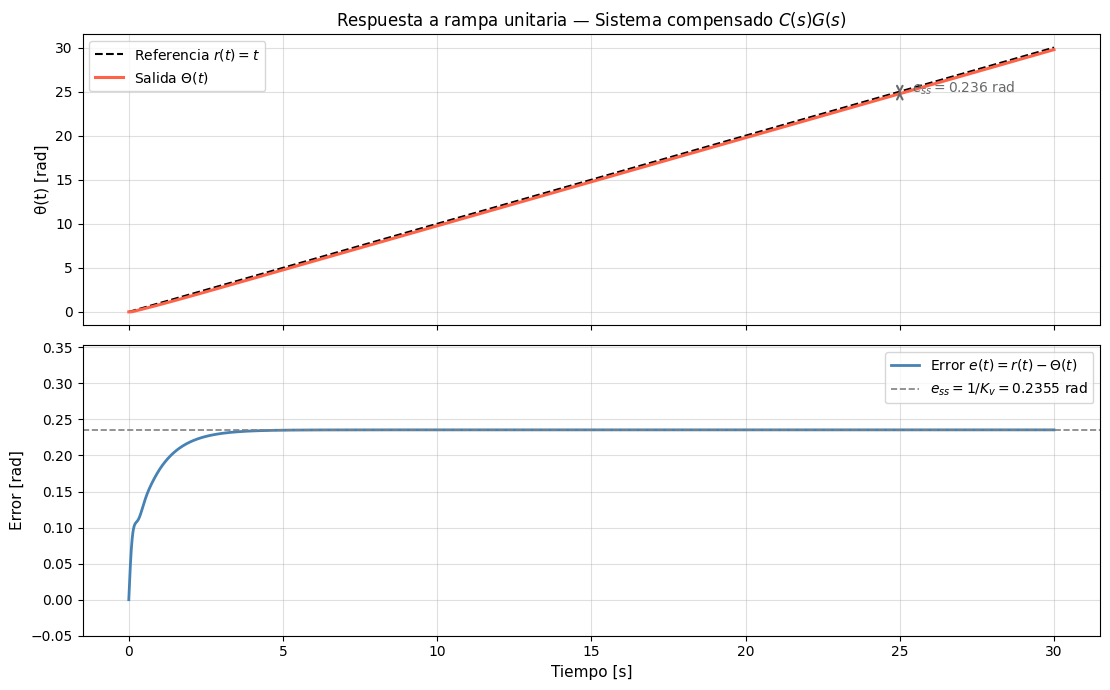

In [24]:

 
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25
 
G      = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
z_ctrl = 1.5;   K_ctrl = 2.2643
C      = ctrl.tf([K_ctrl, K_ctrl * z_ctrl], [1])
G_cl   = ctrl.feedback(ctrl.series(C, G), 1)
 
# constante de error de velocidad Kv 
Kv       = K_ctrl * z_ctrl * Kt / (R * B + Ke * Kt)
e_ss     = 1.0 / Kv
print(f"Constante de velocidad:  Kv  = {Kv:.4f} rad⁻¹")
print(f"Error régimen permanente: ess = 1/Kv = {e_ss:.4f} rad")
 
# simulacion con rampa unitaria 
t        = np.linspace(0, 30, 10000)
ramp     = t                                    # r(t) = t
 
t_out, y_ramp = ctrl.forced_response(G_cl, T=t, U=ramp)
error_t  = t_out - y_ramp                       # e(t) = r(t) - y(t)
 
print(f"\nError simulado en t = 20 s: {np.interp(20, t_out, error_t):.4f} rad")
print(f"Error simulado en t = 30 s: {np.interp(30, t_out, error_t):.4f} rad")
print(f"Convergencia a 1/Kv = {e_ss:.4f} rad")
 
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
 
ax1 = axes[0]
ax1.plot(t_out, t_out,   'k--', lw=1.5, label='Referencia $r(t) = t$')
ax1.plot(t_out, y_ramp, color='tomato', lw=2.2, label='Salida $\\Theta(t)$')
 
t_mark = 25
y_mark = float(np.interp(t_mark, t_out, y_ramp))
ax1.annotate('', xy=(t_mark, t_mark), xytext=(t_mark, y_mark),
             arrowprops=dict(arrowstyle='<->', color='dimgray', lw=1.5))
ax1.annotate(f'$e_{{ss}} = {e_ss:.3f}$ rad',
             xy=(t_mark + 0.4, (t_mark + y_mark) / 2),
             color='dimgray', fontsize=10)
 
ax1.set_ylabel('θ(t) [rad]', fontsize=11)
ax1.set_title('Respuesta a rampa unitaria — Sistema compensado $C(s)G(s)$', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)
 
ax2 = axes[1]
ax2.plot(t_out, error_t, color='steelblue', lw=2, label='Error $e(t) = r(t) - \\Theta(t)$')
ax2.axhline(e_ss, color='gray', lw=1.2, ls='--',
            label=f'$e_{{ss}} = 1/K_v = {e_ss:.4f}$ rad')
ax2.set_xlabel('Tiempo [s]', fontsize=11)
ax2.set_ylabel('Error [rad]', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)
ax2.set_ylim(-0.05, e_ss * 1.5)
 
plt.tight_layout()
plt.show()

El sistema sigue la rampa pero con un desfasaje angular constante de aproximadamente 0.2355 rad. 

Esto significa que el ángulo del aspa siempre va a estar ligeramente por detrás de la referencia en régimen permanente.

Este comportamiento es consistente con un sistema de tipo 1, el cual presenta error finito ante una entrada tipo rampa.

e) 

#### Controlador PID para seguimiento de rampa
 
##### ¿Por qué falla el PD ante rampa?
 
El controlador PD $C_{PD}(s) = K(s+z)$ es un sistema de **tipo 0** en sí mismo.
Combinado con la planta (tipo 1), el lazo abierto $C_{PD}(s)\,G(s)$ resulta de
**tipo 1**, lo que garantiza error nulo ante escalón pero error constante
$e_{ss} = 1/K_v = 0{,}2355$ rad ante rampa.
 
Para lograr error nulo ante rampa se necesita que el lazo abierto sea de
**tipo 2**, es decir, que tenga **dos integradores**.
 
---
 
### Solución: agregar un integrador al controlador
 
La modificación más común es incorporar un polo en el origen al controlador PD,
convirtiéndolo en un **PID con estructura de polos y ceros**:
 
$$\boxed{C_{nuevo}(s) = K \cdot \frac{(s + z_1)(s + z_2)}{s}}$$
 
El denominador $s$ es el integrador adicional. Los dos ceros $z_1$ y $z_2$ sirven para:
 
- **$z_1 = 1{,}5$**: el cero del diseño original, que ya sabemos que funciona.
- **$z_2 = 0{,}1$**: cero nuevo, ubicado cerca del origen para "acompañar" al integrador
  y evitar que el polo en $s=0$ del controlador desestabilice el sistema. Al estar
  próximo al nuevo polo en $s=0$, produce una **cancelación aproximada** que preserva
  la dinámica del diseño original.
Con $K = 2{,}0$, el controlador queda:
 
$$C_{nuevo}(s) = \frac{2{,}0\,s^2 + 3{,}2\,s + 0{,}3}{s}$$
 
---
 
### Tipo del sistema resultante y error ante rampa
 
El lazo abierto $C_{nuevo}(s)\,G(s)$ tiene **dos polos en el origen** (uno de la
planta y uno del controlador), por lo que el sistema es de **tipo 2**:
 
$$K_a = \lim_{s \to 0}\, s^2\, C_{nuevo}(s)\, G(s)$$
 
Para un sistema tipo 2, los errores en régimen permanente son:
 
| Entrada | Error $e_{ss}$ |
|---|---|
| Escalón | 0 |
| Rampa | **0** |
| Parábola | $1/K_a$ |
 
El error ante rampa es exactamente cero.
 
---
 
### Efecto del polo lento en $s \approx -0{,}103$
 
El integrador nuevo introduce un polo del lazo cerrado en $s \approx -0{,}103$.
Este polo tiene un tiempo de establecimiento asociado de $t_s \approx 4/0{,}103 \approx 39$ s,
lo que significa que la convergencia del error a cero es **lenta**.
 
Sin embargo, esto no viola las especificaciones: el requerimiento de $t_s \leq 7{,}5$ s
aplica a la respuesta al escalón, donde el polo lento prácticamente no se activa
porque el cero del lazo cerrado en $s = -0{,}1$ casi lo cancela.

Controlador PID:
  C(s) = 2.0·(s+1.5)·(s+0.1) / s
       = (2.0·s² + 3.200·s + 0.300) / s

Integradores en lazo abierto: 2  -  sistema tipo 2
Error en régimen permanente ante rampa: 0 (exacto)

Polos LC: [-7.9631+12.2494j -7.9631-12.2494j -1.1376 +0.j     -0.103  +0.j    ]
Ceros LC: [-1.5+0.j -0.1+0.j]
  SPECS — CONTROLADOR PID
  Sobrepico    Mp  = 1.36 %    (req ≤ 15 %)
  Tiempo est.  ts  = 1.64 s    (req ≤ 7.5 s)
  Error pert.  ess = 0.76 %    (req < 5 %)
  Error rampa  ess = 0.000078 rad  (req = 0)

  Nota: polo lento en s≈-0.103 - transitorio de rampa dura ≈39 s


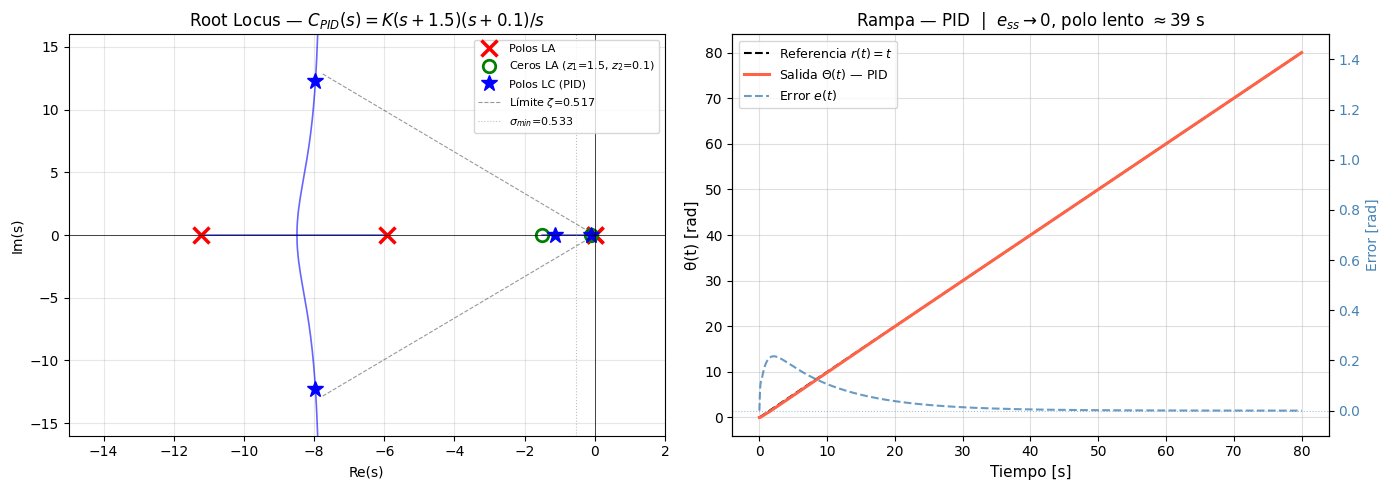

In [25]:
 
L  = 0.15;  R  = 0.7;  Ke = 0.1
J  = 0.02;  B  = 0.25; Kt = 0.25

G     = ctrl.tf([Kt], [L*J, J*R + B*L, B*R + Ke*Kt, 0])
G_mec = ctrl.tf([Kt], [J, B, 0])
 
# controlador PID
z1 = 1.5;  z2 = 0.1;  K_pid = 2.0
 
num_C = [K_pid, K_pid*(z1+z2), K_pid*z1*z2]
den_C = [1, 0]
C_pid = ctrl.tf(num_C, den_C)
 
print("Controlador PID:")
print(f"  C(s) = {K_pid}·(s+{z1})·(s+{z2}) / s")
print(f"       = ({num_C[0]}·s² + {num_C[1]:.3f}·s + {num_C[2]:.3f}) / s")
 
# verif de tipo del sistema
CG   = ctrl.series(C_pid, G)
poles_CG = ctrl.poles(CG)
n_int = sum(1 for p in poles_CG if abs(p) < 1e-6)
print(f"\nIntegradores en lazo abierto: {n_int}  -  sistema tipo {n_int}")
print(f"Error en régimen permanente ante rampa: {'0 (exacto)' if n_int >= 2 else '1/Kv ≠ 0'}")
 
# sist en lazo cerrado
G_cl = ctrl.feedback(ctrl.series(C_pid, G), 1)
T_N  = ctrl.series(G_mec, ctrl.feedback(ctrl.tf([1],[1]), ctrl.series(C_pid, G)))
 
print(f"\nPolos LC: {np.round(ctrl.poles(G_cl), 4)}")
print(f"Ceros LC: {np.round(ctrl.zeros(G_cl), 4)}")
 
# simulacion — escalon + perturb
t_step = np.linspace(0, 20, 10000)
_, y_step = ctrl.step_response(G_cl, T=t_step)
_, y_pert = ctrl.step_response(T_N,  T=t_step)
y_pert = 0.2 * y_pert
 
y_inf = y_step[-1]
Mp    = (np.max(y_step) - y_inf) / y_inf * 100
fuera = np.where((y_step > y_inf*1.02) | (y_step < y_inf*0.98))[0]
ts    = t_step[fuera[-1]] if len(fuera) > 0 else 0.0
ep    = abs(y_pert[-1]) * 100
 
# simulacion— rampa (t largo para ver convergencia)
t_ramp        = np.linspace(0, 80, 20000)
t_r, y_ramp   = ctrl.forced_response(G_cl, T=t_ramp, U=t_ramp)
error_ramp    = t_r - y_ramp
ess_ramp_sim  = abs(error_ramp[-1])

print("  SPECS — CONTROLADOR PID")
print(f"  Sobrepico    Mp  = {Mp:.2f} %    (req ≤ 15 %)")
print(f"  Tiempo est.  ts  = {ts:.2f} s    (req ≤ 7.5 s)")
print(f"  Error pert.  ess = {ep:.2f} %    (req < 5 %)")
print(f"  Error rampa  ess = {ess_ramp_sim:.6f} rad  (req = 0)")
print(f"\n  Nota: polo lento en s≈-0.103 - transitorio de rampa dura ≈{4/0.103:.0f} s")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ax1 = axes[0]
CG_nok = ctrl.series(ctrl.tf([1, z1+z2, z1*z2], [1, 0]), G)
try:
    rlist, klist = ctrl.root_locus_plot(CG_nok, plot=False)
    for branch in range(rlist.shape[1]):
        ax1.plot(np.real(rlist[:, branch]), np.imag(rlist[:, branch]),
                 'b-', lw=1.2, alpha=0.6)
except: pass
 
poles_ol = ctrl.poles(CG_nok)
zeros_ol = ctrl.zeros(CG_nok)
poles_lc = ctrl.poles(G_cl)
ax1.plot(np.real(poles_ol), np.imag(poles_ol),
         'rx', ms=11, mew=2.5, label='Polos LA')
ax1.plot(np.real(zeros_ol), np.imag(zeros_ol),
         'go', ms=9,  mew=2,   mfc='none', label=f'Ceros LA ($z_1$={z1}, $z_2$={z2})')
ax1.plot(np.real(poles_lc), np.imag(poles_lc),
         'b*', ms=12, label='Polos LC (PID)')
 
theta_spec = np.arccos(0.517); r_max = 15
ax1.plot([0, -r_max*np.cos(theta_spec)], [0,  r_max*np.sin(theta_spec)],
         'k--', lw=0.8, alpha=0.4, label='Límite $\\zeta$=0.517')
ax1.plot([0, -r_max*np.cos(theta_spec)], [0, -r_max*np.sin(theta_spec)],
         'k--', lw=0.8, alpha=0.4)
ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)
ax1.axvline(-4/7.5, color='gray', lw=0.8, ls=':', alpha=0.5,
            label='$\\sigma_{min}$=0.533')
ax1.set_xlim(-15, 2); ax1.set_ylim(-16, 16)
ax1.set_xlabel('Re(s)'); ax1.set_ylabel('Im(s)')
ax1.set_title(f'Root Locus — $C_{{PID}}(s) = K(s+{z1})(s+{z2})/s$')
ax1.legend(fontsize=8, loc='upper right'); ax1.grid(True, alpha=0.3)
 
ax2 = axes[1]
ax2.plot(t_r, t_r,    'k--', lw=1.5, label='Referencia $r(t)=t$')
ax2.plot(t_r, y_ramp, color='tomato', lw=2.2, label='Salida $\\Theta(t)$ — PID')
 
ax2b = ax2.twinx()
ax2b.plot(t_r, error_ramp, color='steelblue', lw=1.5, ls='--',
          alpha=0.8, label='Error $e(t)$')
ax2b.axhline(0, color='steelblue', lw=0.8, ls=':', alpha=0.5)
ax2b.set_ylabel('Error [rad]', color='steelblue', fontsize=10)
ax2b.tick_params(axis='y', labelcolor='steelblue')
ax2b.set_ylim(-0.1, 1.5)
 
ax2.set_xlabel('Tiempo [s]', fontsize=11)
ax2.set_ylabel('θ(t) [rad]', fontsize=11)
ax2.set_title(f'Rampa — PID  |  $e_{{ss}}\\to 0$, polo lento $\\approx${4/0.103:.0f} s', fontsize=12)
 
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.4)
 
plt.tight_layout()
plt.show()

El controlador modificado $C_{nuevo}(s) = 2{,}0\,(s+1{,}5)(s+0{,}1)/s$ resuelve el
problema de seguimiento de rampa **sin violar ninguna de las especificaciones anteriores**.
 
### Tabla comparativa de los 3 casos
 
| Especificación | Req. | Sin compensar | PD | **PID** |
|---|---|---|---|---|
| $M_p$ | ≤ 15 % | 0.02 % | 0.00 % | **1.36 %** |
| $t_s$ | ≤ 7.5 s | 2.05 s | 1.99 s | **1.64 s** |
| Error pert. (0.2) | < 5 % | 14.00 % | 4.71 % | **0.76 %** |
| Error ante rampa | = 0 | 0.235 rad | 0.235 rad | **0 rad** |
  
**¿Por qué funciona?** El integrador agregado en el controlador lleva el sistema de tipo 1
a **tipo 2**: el lazo abierto tiene ahora dos polos en el origen, lo que garantiza error
nulo ante cualquier rampa. El cero en $z_2 = 0{,}1$ se ubica muy cerca del nuevo polo en
el origen, produciendo una **cancelación aproximada** que preserva la dinámica
rápida del diseño con PD.
 
**El polo lento en $s \approx -0{,}103$** es consecuencia inevitable del integrador adicional.
Tiene un tiempo de establecimiento de ~39 s, pero solo afecta la respuesta a rampa
(el error converge lentamente a cero). Para la respuesta al escalón, el cero del
lazo cerrado en $s = -0{,}1$ casi lo cancela y el transitorio sigue siendo rápido.
 
**El error ante perturbación mejora significativamente** (de 4.71% a 0.76%) porque
el integrador en el controlador elimina el efecto de cargas constantes en régimen
permanente — es el mismo principio que el controlador PI clásico.

## Ejercicio 2

### Análisis y Control frente a Perturbaciones


Durante ensayos en túnel de viento, se detectó que el coeficiente de fricción viscosa
$B$ puede degradarse por fatiga del material o variaciones térmicas, llegando incluso
a tomar **valores negativos** y comprometiendo la estabilidad del sistema.

Para este análisis se utiliza un modelo simplificado que desprecia la dinámica eléctrica
(asumiendo que su constante de tiempo es significativamente menor que la mecánica),
quedando el sistema descripto por:

$$G(s) = \frac{\Theta(s)}{V(s)} = \frac{K}{s(Js + B)}$$

con $K = 1$ y $J = 1$. El parámetro $B$ es la fuente de incertidumbre: en condiciones
nominales $B = 0{,}5$, pero ante la falla modelada cae a $B = -0{,}1$.

El análisis se divide en dos partes. En la **Parte A** se caracteriza la sensibilidad
del sistema frente a esta falla: se estudia la estabilidad mediante el criterio de
Nyquist, se simula la transición abrupta entre el sistema nominal y el fallado, y se
analiza el desplazamiento de los polos en el lugar de raíces para entender por qué
el sistema colapsa. En la **Parte B** se diseña un compensador que incremente los
**márgenes de fase** del sistema nominal a $35°$, $50°$ y $65°$, garantizando
estabilidad robusta aun cuando $B$ tome valores negativos, y se analiza el impacto
de cada nivel de margen sobre la respuesta transitoria del sistema.

### Parte A - Análisis de Sensibilidad y Robustez
Se caracteriza el comportamiento del sistema frente a la degradación del parámetro $B$.
Partiendo del sistema nominal ($B = 0{,}5$) con realimentación unitaria, se analiza la
estabilidad mediante el **criterio de Nyquist** y se simula la respuesta al escalón
ante una falla abrupta en $t = 15\,\text{s}$, donde $B$ pasa de $0{,}5$ a $-0{,}1$.
El estudio del **lugar de raíces** para ambos casos permite entender el desplazamiento
de los polos y explicar por qué el sistema, estable en condiciones nominales, colapsa
ante la degradación. Con base en estos resultados se justifica la elección del tipo de
compensador adecuado para otorgar robustez frente a esta variación paramétrica.

In [2]:
def plant(B_val):
    num = [1]
    den = [1, B_val, 0]
    return ctrl.tf(num, den)

In [3]:
G_B05 = plant(0.5)
G_B01 = plant(-0.1)

G_B05_closed = ctrl.feedback(G_B05, 1)
G_B01_closed = ctrl.feedback(G_B01, 1)

a) 

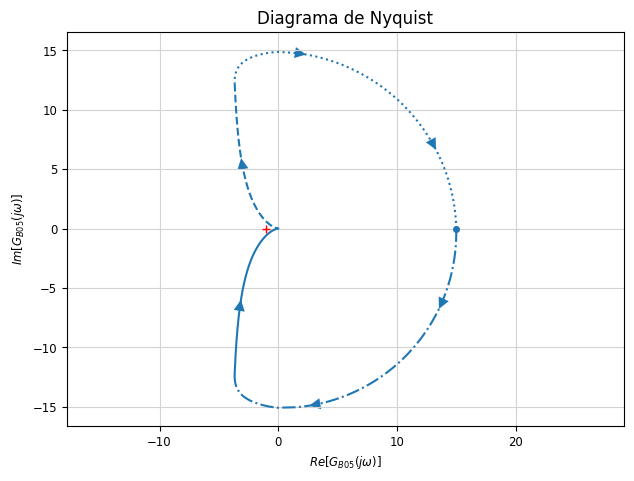

In [4]:
plt.figure()
ctrl.nyquist_plot(G_B05, title='')
plt.title('Diagrama de Nyquist')
plt.xlabel('$Re[G_{B05}(j\\omega)]$')
plt.ylabel('$Im[G_{B05}(j\\omega)]$')
plt.grid(True)
plt.axis('equal')
plt.show()

##### A partir del criterio de estabilidad de Nyquist, se puede observar que el sistema es estable en lazo cerrado:
- $P = 0$ (cantidad de polos del sistema a lazo abierto que estan en el RHP)
- $N = 0$ (cantidad de vueltas alrededor de $-1+j0$)
- $Z = P - N$ donde $Z$ es la cantidad de polos del sistema a lazo cerrado en el RHP, el cual es $Z = 0$

b) 

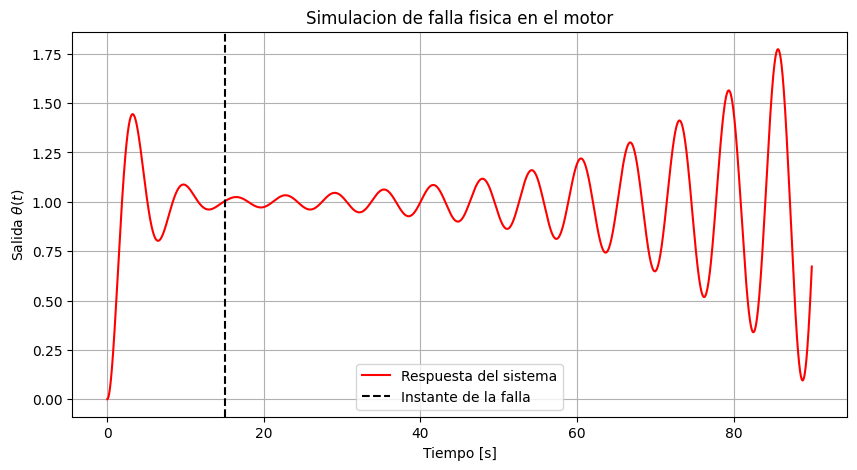

In [5]:
# Tiempos de simulacion
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 90, 3000)

# Sistema con B=0.5
sys1 = ctrl.ss(G_B05_closed)
response1 = ctrl.forced_response(sys1, T=t1, U=1)
t_out1 = response1.time
y_out1 = response1.outputs
x_out1 = response1.states
x_final_stage1 = x_out1[:, -1]

# Sistema con B=-0.1
sys2 = ctrl.ss(G_B01_closed)
response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
t_out2 = response2.time
y_out2 = response2.outputs
x_out2 = response2.states

t_total = np.concatenate([t_out1, t_out2])
y_total = np.concatenate([y_out1, y_out2])

plt.figure(figsize=(10, 5))
plt.plot(t_total, y_total, label='Respuesta del sistema', color='red')
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

c)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


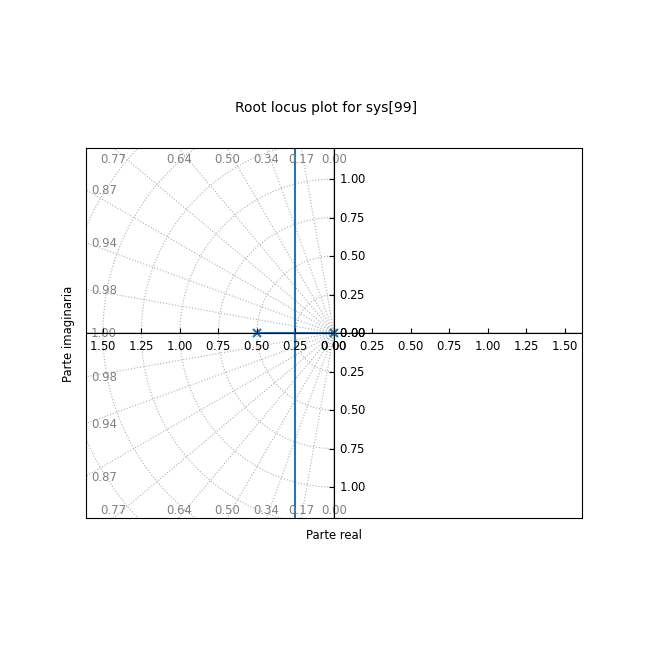

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


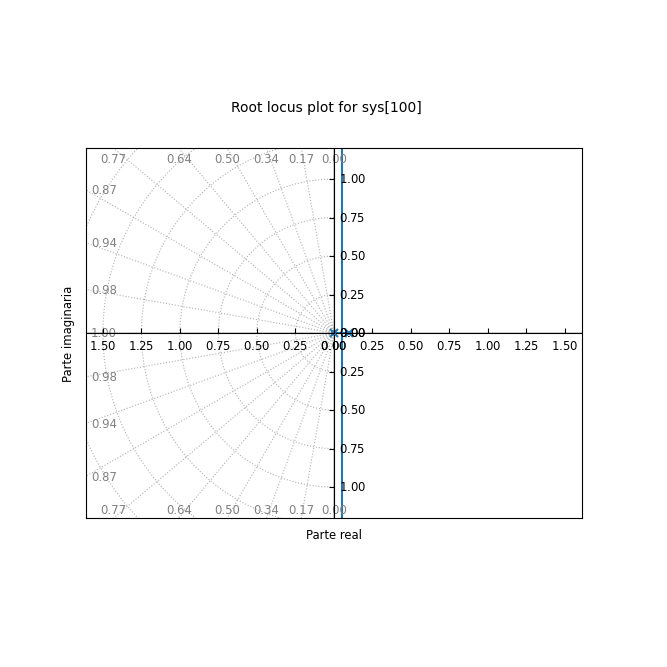

In [30]:
ctrl.root_locus(G_B05)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

ctrl.root_locus(G_B01)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

##### La estabilidad depende del valor de B: la función de transferencia es $\tfrac{K}{s(Js+B)}=\tfrac{1}{s(s+B)}$, los polos del sistema son $s=0$ y $s=-B$
##### De esta manera:
- Con $B>0$ el polo tiene parte real negativa, por lo que el sistema es estable.
- Con $B<0$ el polo tiene parte real positiva, por lo que el sistema es inestable.
- Con $B=0$ hay doble polo en cero, po rlo que el sistema se vuelve marginalmente estable (oscila).

##### En cuanto a la robustez, frente a un cambio pequeño que cruce el eje imaginario destruye el control del sistema. Además, incluso si $B$ se mantiene positivo, el sistema es sensible (si $B$ disminuye aparecen oscilaciones o sobrepicos y si aumenta mucho el sistema se vuelve muy lento)

d)

##### A partir de los resultados anteriores, el tipo de compensador que se considera adecuado es un compensador en adelanto. Esta elección se debe a que el sistema tiene un polo en el origen ($s=0$) que aporta -90° de fase, y un segundo polo en $s=-B$ el cual aporta de manera distinta a la fase:
- B>0: polo estable, la fase total tiende a -180° pero no la alcanza.
- B=0: polo doble en el origen, con fase constante de -180°, lo que hace que el sistema sea marginalmente estable (oscila).
- B<0: la fase cae por debajo de los -180°, por lo que convierte al sistema en inestable.
##### De esta manera, el compensador en adelanto agregaria fase positiva al sistema en lazo abierto, incrementando el margen de fase, permitiendo que el sistema soporte la falla.

### Parte B — Diseño de Compensador para Estabilidad Robusta

Se diseña el compensador seleccionado en la Parte A con el objetivo de incrementar el
**margen de fase** del sistema nominal ($B = 0{,}5$) a tres niveles: $35°$, $50°$ y
$65°$. En cada caso se normaliza la ganancia DC del compensador para no alterar el
error de posición en régimen permanente. Se verifican los márgenes obtenidos en el
**diagrama de Bode** y se simula la respuesta al escalón ante la falla en $t = 15\,\text{s}$,
comparando los tiempos de establecimiento entre los tres diseños. Finalmente, se analiza
el efecto del compensador sobre el **diagrama de Nyquist** y se discuten las desventajas
de incrementar indefinidamente el margen de fase.

a) 
Para este inciso, se usó un compensador en adelanto de la forma $C(s) = k\tfrac{s+1}{s+k}$, el cual es un compensador normalizado que no genera cambios bruscos en la ganancia de estado estacionario, esto se puede ver con $lim_{s\rightarrow 0} C(s) = lim_{s\rightarrow 0} k\tfrac{s+1}{s+k} = 1$.  

Como un compensador en adelanto tiene el cero a la derecha del polo y este compensador tiene un cero en $s = -1$ y un polo en $s = -k$, entonces $k > 1$. Para el diseño del compensador, se varía el valor de k, desde 1.1, hasta llegar al valor del margen de fase deseado.  

Este tipo de compensador se puede usar porque permite aumentar el margen de fase del sistema, permitiendo la mejora en la estabilidad frente a variaciones de B. Introduce fase positiva, lo que ayuda a compensar el efecto de los polos de la planta que aportan fase negativa. Además, al estar normalizado no modifica el comportamiento en régimen permanente ni el error de estado estacionario.

In [6]:
def compensador(z):
    num = [z, z]
    den = [1, z]
    return ctrl.tf(num, den)

In [7]:
z_values = np.linspace(1.1, 50, 100000)
objetivos = [35, 50, 65]
z_encontrados = [None, None, None]

for z in z_values:
    C = compensador(z)
    L = C * G_B05
    _, pm, _, _ = ctrl.margin(L)

    for i, objetivo in enumerate(objetivos):
        if z_encontrados[i] is None and pm >= objetivo:
            z_encontrados[i] = z

    if all(v is not None for v in z_encontrados):
        break

print('Resultados:')
for objetivo, z in zip(objetivos, z_encontrados):
    print(f'Para MF={objetivo}°: z={z}')

Resultados:
Para MF=35°: z=1.360639606396064
Para MF=50°: z=2.746479464794648
Para MF=65°: z=8.745102451024511


b) 

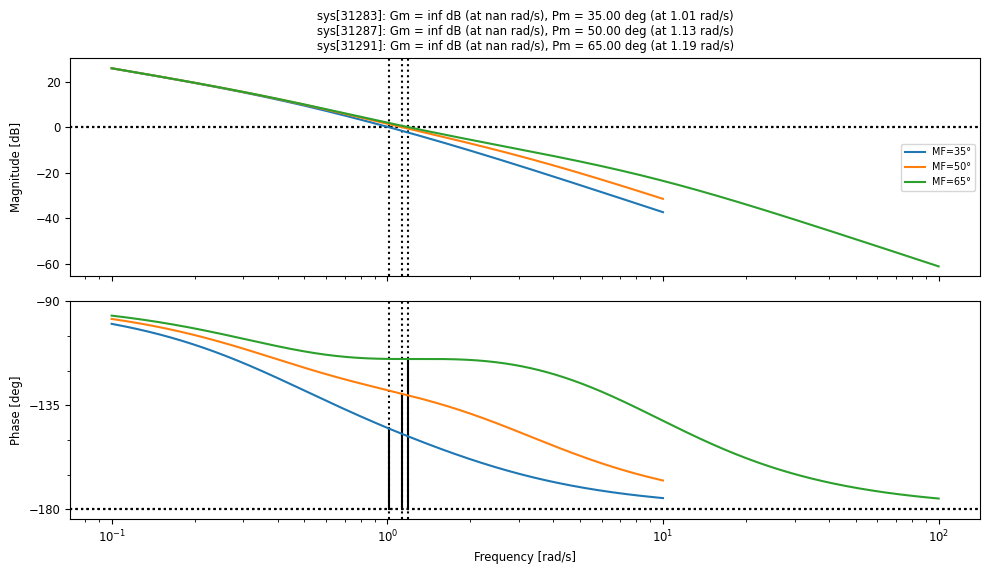

In [8]:
plt.figure(figsize=(10, 6))

for z in z_encontrados:
    C = compensador(z)
    L = C * G_B05
    
    gm, pm , wg , wp = ctrl.margin(L)
    
    ctrl.bode_plot(L, dB=True, deg=True, display_margins=True, label=f'MF={pm:.0f}°')

plt.show()

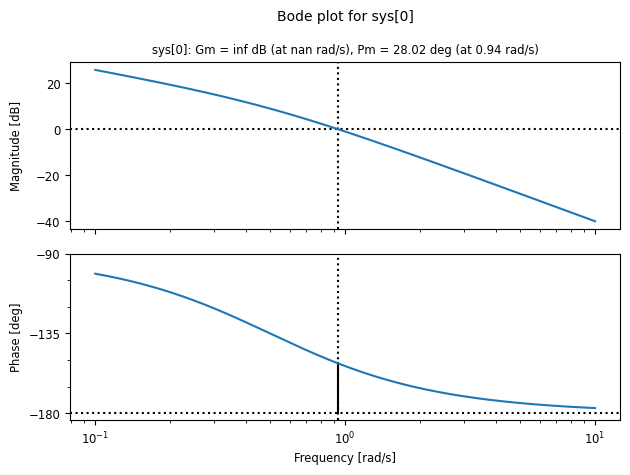

In [9]:
ctrl.bode_plot(G_B05, dB=True , deg=True , display_margins=True)
plt.show()

c) 

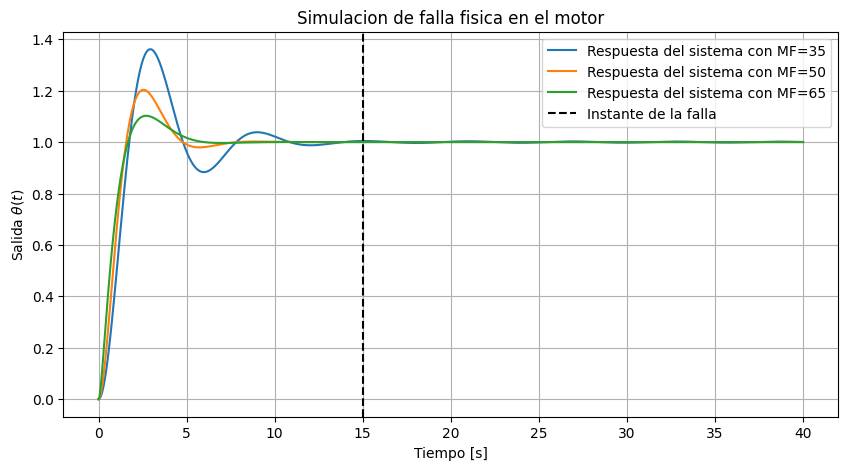

In [10]:
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 40, 3000)

plt.figure(figsize=(10, 5))

for z, label in zip(z_encontrados, objetivos):
    C = compensador(z)
    L_B05 = C * G_B05
    L_B01 = C * G_B01
    L_B05_closed = ctrl.feedback(L_B05, 1)
    L_B01_closed = ctrl.feedback(L_B01, 1)

    # Sistema con B=0.5
    sys1 = ctrl.ss(L_B05_closed)
    response1 = ctrl.forced_response(sys1, T=t1, U=1)
    t_out1 = response1.time
    y_out1 = response1.outputs
    x_out1 = response1.states
    x_final_stage1 = x_out1[:, -1]

    # Sistema con B=-0.1
    sys2 = ctrl.ss(L_B01_closed)
    response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
    t_out2 = response2.time
    y_out2 = response2.outputs
    x_out2 = response2.states

    t_total = np.concatenate([t_out1, t_out2])
    y_total = np.concatenate([y_out1, y_out2])

    plt.plot(t_total, y_total, label=f'Respuesta del sistema con MF={label}')
 
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

##### Análisis de tiempos de establecimiento
 
Los polos dominantes del lazo cerrado y los tiempos de establecimiento para cada compensador son:
 
| Compensador | $z$ | Polo dominante | $\zeta$ | $t_s$ nominal |
|---|---|---|---|---|
| MF = 35° | 1.361 | $-0.369 \pm j1.037$ | 0.335 | 9.90 s |
| MF = 50° | 2.747 | $-0.719 \pm j1.001$ | 0.584 | 5.95 s |
| MF = 65° | 8.745 | $-0.779 \pm j0.728$ | 0.731 | 4.87 s |
 
A medida que se incrementa el margen de fase, el factor de amortiguamiento $\zeta$ crece
y el tiempo de establecimiento **disminuye**: el sistema responde más rápido y con menos
oscilaciones. Esto se puede observar claramente en el gráfico: con MF = 35° la respuesta
presenta un sobrepico apreciable (~36%) y oscilaciones que se extienden hasta ~10 s;
con MF = 50° el sobrepico se reduce (~20%) y desaparece antes; con MF = 65° la
respuesta es casi monótona, con sobrepico mínimo (~10%) y establecimiento en ~5 s.
 
En el límite, cuando $\zeta \to 1$, el par de polos complejos conjugados se aproxima a
dos polos reales iguales. Por eso, **a mayor MF, el sistema se parece cada vez más a
un sistema críticamente amortiguado** ($\zeta = 1$): respuesta exponencial sin
oscilaciones, que alcanza el valor final de forma monótona.
 
En cuanto a la falla en $t = 15$ s: los tres sistemas ya se habían establecido antes de
que ocurra el cambio $B = 0{,}5 \to -0{,}1$, y los tres se mantienen estables después de
ella, convergiendo nuevamente a 1 rad. Esto confirma que el compensador lead otorga
el margen de seguridad necesario para tolerar la degradación del parámetro $B$.

d) 

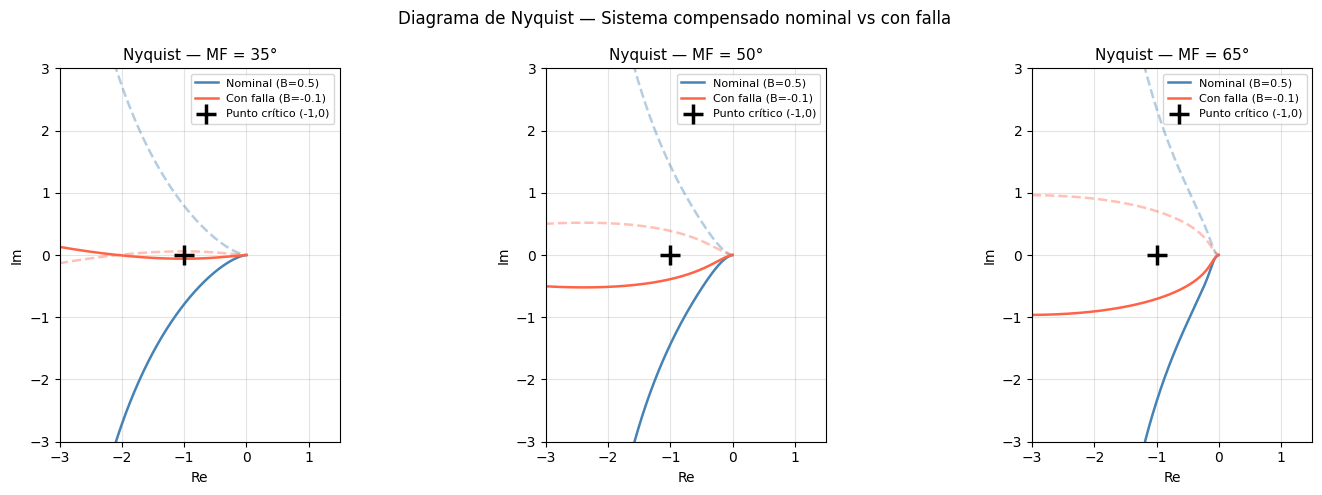

In [39]:
# ============================================================
# INCISO B.d) — Diagrama de Nyquist del sistema compensado
# Nominal (B=0.5) vs con falla (B=-0.1), para los 3 compensadores
# ============================================================

omega = np.logspace(-2, 2, 2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, z, label in zip(axes, z_encontrados, labels):
    C       = compensador(z)
    L       = C * G_B05
    L_falla = C * G_B01

    # Evaluación manual en jω para tener control total del estilo
    L_jw       = np.array([L(1j*w)       for w in omega])
    L_falla_jw = np.array([L_falla(1j*w) for w in omega])

    # Curva nominal + espejo (ω negativo)
    ax.plot(np.real(L_jw),        np.imag(L_jw),        color='steelblue', lw=1.8,
            label='Nominal (B=0.5)')
    ax.plot(np.real(L_jw),       -np.imag(L_jw),        color='steelblue', lw=1.8,
            ls='--', alpha=0.4)

    # Curva con falla + espejo
    ax.plot(np.real(L_falla_jw),  np.imag(L_falla_jw),  color='tomato', lw=1.8,
            label='Con falla (B=-0.1)')
    ax.plot(np.real(L_falla_jw), -np.imag(L_falla_jw),  color='tomato', lw=1.8,
            ls='--', alpha=0.4)

    ax.plot(-1, 0, 'k+', ms=14, mew=2.5, label='Punto crítico (-1,0)')
    ax.set_title(f'Nyquist — MF = {label}', fontsize=11)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_xlim(-3, 1.5); ax.set_ylim(-3, 3)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.35)
    ax.set_aspect('equal')

plt.suptitle('Diagrama de Nyquist — Sistema compensado nominal vs con falla', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. ¿Cómo el compensador "aleja" la curva del punto crítico (-1, 0)?
 
El compensador en adelanto $C(s) = k\tfrac{s+1}{s+k}$ aporta **fase positiva** en el
rango de frecuencias cercano a $\omega_{gc}$. Esto produce un efecto geométrico directo
sobre el diagrama de Nyquist: la curva $C(j\omega)G(j\omega)$ se "rota" en sentido
antihorario respecto a la curva sin compensar $G(j\omega)$, alejándose del punto
crítico $(-1, 0)$.
 
En los diagramas se puede observar:
 
- **Sin compensar (Parte A):** la curva cruza el eje real negativo relativamente cerca
  de $-1$, dejando poco margen.
- **Compensado nominal (B=0.5, curva azul):** la curva pasa notoriamente más lejos de
  $(-1, 0)$ — ese alejamiento es exactamente el margen de fase ganado. A mayor MF
  diseñado, mayor es la distancia al punto crítico.
- **Con falla (B=-0.1, curva roja):** la degradación de $B$ deforma la curva y la
  acerca al punto crítico. Sin embargo, gracias al margen adicional introducido por el
  compensador, **la curva sigue sin rodearlo** ($N = 0$, $P = 0$, $Z = 0$), por lo que
  el sistema en lazo cerrado se mantiene estable.
A mayor MF diseñado, mayor es la distancia de seguridad entre la curva nominal y el
punto $(-1, 0)$, y mayor es el colchón disponible para tolerar la degradación de $B$.


##### 2. ¿Qué desventajas observa al seguir incrementando el MF?
 
Aumentar el margen de fase mediante este compensador implica aumentar el valor de $k$
(de 1.36 a 2.75 a 8.75 en nuestros tres casos), lo que tiene los siguientes efectos negativos:
 
- **Amplificación de ruido en altas frecuencias:** la ganancia del compensador tiende a
  $|C(j\omega)| \to k$ para $\omega \to \infty$. A mayor $k$, mayor es la amplificación
  del ruido de alta frecuencia en la señal de error, lo que deteriora el desempeño real
  del sistema implementado.
- **Mayor ancho de banda:** el desplazamiento de $\omega_{gc}$ hacia frecuencias más altas
  hace al sistema más sensible a dinámicas no modeladas como flexibilidad estructural,
  retardos de actuación o resonancias mecánicas.
- **Implementación física más exigente:** un compensador con $k$ muy grande requiere
  componentes con tiempos de respuesta muy rápidos (amplificadores, sensores de alta
  velocidad), lo que puede ser costoso o directamente irrealizable en la práctica.
- **Rendimiento decreciente:** como se observa en la tabla del inciso c), pasar de
  MF = 35° a 50° reduce el $t_s$ de 9.90 s a 5.95 s (mejora de ~4 s), pero pasar de
  50° a 65° solo lo reduce de 5.95 s a 4.87 s (mejora de apenas ~1 s), con un $k$ que
  casi se triplica (de 2.75 a 8.75). La ganancia en robustez se vuelve cada vez menor
  en relación al costo.
En conclusión, existe un **trade-off** entre robustez (mayor MF) y desempeño/practicidad:
no conviene seguir incrementando el MF indefinidamente más allá de lo necesario para
garantizar estabilidad ante la falla esperada.